## Copula Fit: Minutes x Points Dependence
**- Owner:** Alex

**- Status:** Exploration only - the exported spec is marked `exploratory_oos` and is not for pricing

**- Last Updated:** 10/4/26

### Purpose

**When the minutes model misses, does scoring miss with it, beyond what the shorter or longer stint explains?**
The simulator draws `U` → minutes through the minutes sampler, then `V | U` → integer points. This notebook fits and tests the copula for `(U, V)`.

### Inputs
**- OOS table:** `data/oos/nba/minutes_rate_oos.parquet`. Walk-forward windows 1-5 only (2022-11 → 2025-04). Rebuilt by `scripts/build_oos_table.py`. 2025-26 rows are dropped on load and kept for the final run.

**- Samplers:** minutes and rate tail sidecars (`min_nba_tails_*`, `pts_nba_tails_*`).

**- Gamelogs:** silver `player_gamelogs` for starter flag, pregame spread, and the EWMA used for pseudo-lines.

**- Odds:** `data/backtest/singleBookies.csv` (`ODDS_PATH`), 2024-25 player props with columns `NAME`, `CATEGORY`, `SIDE`, `BOOKMAKER`, `LINE`, `ODDS` (American), `GAME_DATE`. Points props run 2024-10-23 to 2025-04-12, so they overlap windows 4 and 5. Most of the volume (Feb–Apr) is in window 5. Optional: the market comparison is skipped when the file is missing. Bets need expected value above `EDGE_THRESHOLD`, which is fixed in config before looking at results.

### Outputs
**- Pairs:** `artifacts/nba/copula/rank_pairs.parquet` (`player_id`, `game_id`, `window_id`, `u_minutes`, `u_points`, `u_rate_legacy`)

**- Spec:** `artifacts/nba/copula/copula_spec.json`. It has the family, rotation, parameters, the count model, a `status` field, and lineage. The JSON is enough to rebuild the copula, so no pickle is saved.

**- Comparison:** `artifacts/nba/copula/copula_comparison.csv` and `backtest_scores.csv`

### Method
`u_minutes` is the randomized PIT of realized minutes under that row's minutes sampler (built by `models/shared/copula.py`).
`u_points` is the randomized PIT of realized points under a NegBin count model with *actual* minutes as exposure. The mean is `kappa * m^beta * exp(beta2 * log(m/24)^2) * r_hat`. Dispersion varies with log-minutes and with the rate sampler's coefficient of variation, so a short stint does not push `u_points` down by itself.
Gaussian, Student-t, Clayton, Gumbel (including survival Gumbel), Frank, Joe, BB1, and BB7 are fit by MLE with all rotations (`pyvinecopulib`). Game-level bootstrap intervals are reported.
Selection is out-of-sample with a rolling origin: fit on 1 → score 2, fit on 1-2 → score 3, fit on 1-3 → score 4, fit on 1-4 → score 5. Every fold refits the count model, the copula, and the direct model, then backtests (a) independence, (b) the copula, and (c) a direct points-given-minutes model with the minutes surprise as a feature. The best setup is the one with the highest pooled log score across the four folds. A verdict needs the pooled game-bootstrap interval to exclude zero and every fold to agree on the sign.
The spec exports the family picked out of sample (on the training windows of the last fold), refit on all pairs. If in-sample AIC prefers a different family, that goes into the lineage warnings.

### Key Assumptions
**- Calibrated margins:** a copula reads any miscalibration in either margin as dependence, so both PITs are checked before fitting.

**- Exposure model:** if the count model is wrong about how points scale with minutes, part of that error shows up as dependence. `u_points` is checked against actual-minutes buckets.

**- Pooled dependence:** one copula for all rows. Tier and spread splits are shown, but not yet used in the backtest.

**- Lineup timing:** samplers are conditioned on the actual starter flag. Run with `LINEUPS_KNOWN = False` if you bet before lineups lock.

**- OOS lineage:** the OOS table and both tail sidecars come from `scripts/build_oos_table.py`, run on the prediction files the minutes and points notebooks write after saving their `2026-04-12` bundles. If a bundle is re-saved without rerunning the script, the lineage check flags it. The tail sidecars are fit on folds 1-4 only, so window 5 is out of sample for them too.

### Results
**- Results:** generated from the computed values in the **Results** cell at the end, so they cannot go stale.

### 1. Config and Lineage
Everything downstream depends on which models and which data produced the pairs, so hashes, timestamps, filters, and library versions are recorded first.

In [47]:
from datetime import datetime, timezone
from hashlib import sha256
import json
from pathlib import Path
import platform
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyvinecopulib as pv
import scipy
import statsmodels
from IPython.display import Markdown, display
from scipy import stats

def _repo_root() -> Path:
    starts = []
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        starts.append(Path(nb).resolve().parent)
    starts.append(Path.cwd().resolve())
    for start in starts:
        for candidate in (start, *start.parents):
            if (candidate / "pyproject.toml").is_file():
                return candidate
    raise RuntimeError("could not find repo root (pyproject.toml)")

ROOT = _repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.shared.copula import build_pit_pairs, minutes_tier
from models.shared.metrics import (
    PIT_MEAN_TOLERANCE,
    PIT_TAIL_TOLERANCE,
    PIT_VAR_SCALE_TOLERANCE,
    binary_brier,
    integer_log_score,
    pseudo_lines,
    PSEUDO_LINE_NAMES,
    randomized_pit as pmf_randomized_pit,
    rps,
    seeded_unit_uniform,
)
from models.shared.minutes_sampler import (
    HOLDOUT_START,
    QUANTILE_LEVELS,
    canonical_id,
    groups_for_frame as minutes_groups,
    load_tail_sidecar as load_minutes_tails,
    ppf as minutes_ppf,
)
from models.shared.market import ev_bucket_records, load_single_bookies, no_vig_over, score_market
from models.shared.points_given_minutes import (
    conditional_points_pmf,
    copula_corner_lifts,
    corner_lifts,
    count_pit,
    fit_count_model,
)
from models.shared.ppm_sampler import (
    groups_for_frame as rate_groups,
    load_tail_sidecar as load_rate_tails,
    ppf as rate_ppf,
)
from src.features.minutes.rolling import prior_ewm

warnings.filterwarnings("ignore", category=DeprecationWarning, module="pyvinecopulib")

# ── Copula config ─────────────────────────────────────────────────────────────

SEED = 42
np.random.seed(SEED)

OOS_PATH = ROOT / "data/oos/nba/minutes_rate_oos.parquet"
MINUTES_TAILS_PATH = ROOT / "models/saved_models/min_nba_tails_2026-04-12.joblib"
RATE_TAILS_PATH = ROOT / "models/saved_models/pts_nba_tails_2026-04-12.joblib"
MINUTES_MODEL_PATH = ROOT / "models/saved_models/min_nba_model_2026-04-12.joblib"
PPM_MODEL_PATH = ROOT / "models/saved_models/pts_nba_model_2026-04-12.joblib"
DATA_PATH = ROOT / "data/silver/nba/{season}/regular_season/player_gamelogs.parquet"
OUTPUT_PATH = ROOT / "artifacts/nba/copula"

HOLDOUT_SEASON = "2025-26"
PREHOLDOUT_SEASONS = ["2019-20", "2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]
STARTER_POSITIONS = ["G", "F", "C"]
EWMA_HALFLIFE = 3

TRAIN_WINDOWS = (1, 2, 3, 4)
TEST_WINDOW = 5

RATE_MEAN_GRID = 200
MINUTES_GRID = 50
KMAX = 90
PMF_BATCH_ROWS = 1_000

TIERS = ["<15", "15-24", "24-31", "31+"]
SPREAD_EDGES = (-6.5, 6.5)
ACTUAL_MINUTES_EDGES = [0, 5, 10, 20, 30, 40, 70]
TAIL_LEVELS = [0.10, 0.05, 0.02, 0.01]
DIAG_Q = 0.10
CORNERS = ["low_u_low_v", "low_u_high_v", "high_u_low_v", "high_u_high_v"]

FAMILIES = {
    "gaussian": pv.families.gaussian,
    "student": pv.families.student,
    "clayton": pv.families.clayton,
    "gumbel": pv.families.gumbel,
    "frank": pv.families.frank,
    "joe": pv.families.joe,
    "bb1": pv.families.bb1,
    "bb7": pv.families.bb7,
}
RADIALLY_SYMMETRIC = {"gaussian", "student", "frank"}
SELECTION_CRITERION = "aic"
N_TOP_FAMILIES = 3
FAMILY_NAMES = {family: name for name, family in FAMILIES.items()}
SELECTION_CONTROLS = pv.FitControlsBicop(
    family_set=list(FAMILIES.values()), parametric_method="mle",
    selection_criterion=SELECTION_CRITERION, preselect_families=False,
)

ROLLING_FOLDS = [((1,), 2), ((1, 2), 3), ((1, 2, 3), 4), ((1, 2, 3, 4), 5)]
COMPARISONS = [("a_independent", "b_copula"), ("a_independent", "c_direct"), ("b_copula", "c_direct")]
LINEUPS_KNOWN = True
MIN_SEGMENT_TRAIN = 500

ODDS_PATH = ROOT / "data/backtest/singleBookies.csv"
ODDS_MIN_BOOKS = 1
ODDS_NAME_ALIASES = {
    "ron holland": "ronald holland",
    "jakob poltl": "jakob poeltl",
    "jamie jaquez": "jaime jaquez",
    "kenyon martin": "kj martin",
    "t vukcevic": "tristan vukcevic",
}
EDGE_THRESHOLD = 0.03

BOOT_REPS = 200
SCORE_BOOT_REPS = 1_000
FIXED_LINES = [4.5, 9.5, 14.5, 19.5, 24.5, 29.5]
N_SANITY_DRAWS = 200_000
CORR_TOLERANCE = 0.01
PIT_CLIP = 1e-6
SPEC_STATUS = "exploratory_oos"

HIST_BINS = 20
SCATTER_SIZE = 1.0
SCATTER_ALPHA = 0.15
WINNER_COLOR = "C3"
OTHER_COLOR = "C0"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
RANK_PAIRS_FILE = OUTPUT_PATH / "rank_pairs.parquet"
COMPARISON_FILE = OUTPUT_PATH / "copula_comparison.csv"
BACKTEST_FILE = OUTPUT_PATH / "backtest_scores.csv"
SPEC_FILE = OUTPUT_PATH / "copula_spec.json"
LEGACY_PICKLE = OUTPUT_PATH / "best_copula.pkl"

MINUTES_KNOTS = [f"minutes_q_{level:.2f}" for level in QUANTILE_LEVELS]
RATE_KNOTS = [f"rate_q_{level:.2f}" for level in QUANTILE_LEVELS]

In [48]:
def file_sha256(path: Path) -> str:
    digest = sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1 << 20), b""):
            digest.update(block)
    return digest.hexdigest()


def mtime(path: Path) -> str:
    return datetime.fromtimestamp(path.stat().st_mtime, tz=timezone.utc).isoformat()


lineage_files = {
    "oos_table": OOS_PATH,
    "minutes_tails": MINUTES_TAILS_PATH,
    "rate_tails": RATE_TAILS_PATH,
    "minutes_bundle": MINUTES_MODEL_PATH,
    "ppm_bundle": PPM_MODEL_PATH,
    **{f"gamelogs_{season}": Path(str(DATA_PATH).format(season=season)) for season in PREHOLDOUT_SEASONS},
}
lineage = {
    name: {
        "path": str(path.relative_to(ROOT)),
        "sha256": file_sha256(path),
        "modified": mtime(path),
    }
    for name, path in lineage_files.items()
}
versions = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "statsmodels": statsmodels.__version__,
    "pyvinecopulib": pv.__version__,
}
lineage_warnings = []
oos_time = OOS_PATH.stat().st_mtime
for name in ("minutes_bundle", "ppm_bundle"):
    if lineage_files[name].stat().st_mtime > oos_time:
        lineage_warnings.append(
            f"{name} was saved after the OOS table, so the pairs describe the earlier fold models."
        )
for name in ("minutes_tails", "rate_tails"):
    if abs(lineage_files[name].stat().st_mtime - oos_time) > 86_400:
        lineage_warnings.append(f"{name} and the OOS table were written more than a day apart.")

display(pd.DataFrame(lineage).T.assign(sha256=lambda f: f["sha256"].str[:12]))
display(pd.Series(versions, name="version").to_frame())
print("Filters: pre-holdout walk-forward rows only, minutes > 0 (OOS contract), regular season.")
for warning in lineage_warnings:
    print("WARNING:", warning)

,path,sha256,modified
oos_table,data/oos/nba/minutes_rate_oos.parquet,b45d7306db6f,2026-10-05T16:51:38.676031+00:00
minutes_tails,models/saved_models/min_nba_tails_2026-04-12.j...,ae075a270ad2,2026-10-05T16:51:38.682035+00:00
rate_tails,models/saved_models/pts_nba_tails_2026-04-12.j...,4c7ce826fa64,2026-10-05T16:51:38.688605+00:00
minutes_bundle,models/saved_models/min_nba_model_2026-04-12.j...,8a6f3aac07b6,2026-10-05T14:10:53.823360+00:00
ppm_bundle,models/saved_models/pts_nba_model_2026-04-12.j...,ccce7d4bebb9,2026-10-05T16:46:31.219711+00:00
gamelogs_2019-20,data/silver/nba/2019-20/regular_season/player_...,1e69babd527c,2026-09-13T04:15:34.206270+00:00
gamelogs_2020-21,data/silver/nba/2020-21/regular_season/player_...,53a0f424d474,2026-09-13T04:02:04.379038+00:00
gamelogs_2021-22,data/silver/nba/2021-22/regular_season/player_...,7af48f3ce7c7,2026-09-11T02:08:51.973792+00:00
gamelogs_2022-23,data/silver/nba/2022-23/regular_season/player_...,34448e7b8742,2026-09-11T02:29:31.377609+00:00
gamelogs_2023-24,data/silver/nba/2023-24/regular_season/player_...,a35b32701213,2026-09-11T02:40:56.463014+00:00


,version
python,3.12.10
numpy,2.5.3
pandas,3.0.5
scipy,1.18.1
statsmodels,0.14.6
pyvinecopulib,1.0.0


Filters: pre-holdout walk-forward rows only, minutes > 0 (OOS contract), regular season.


#### Feature timing and training notes
**- `starter_rank`, `min_avg_lN`, `start_rate_*`:** prior games only (`shift(1)`). Now shared as `src/features/minutes/starters.py`, and a parity test pins it to the original notebook block.

**- `starter_min_missing_teammates`:** reads whether each main starter appeared in *this* game. Gamelogs only contain players who appeared, so an absent starter is an inactive or a DNP. That is known at bet time only after inactives are confirmed. A coach's-decision DNP is not known before tip.

**- `starting`:** the actual start flag from the box score. Both models and both samplers' tail groups use it, so live residuals before lineups are confirmed will be wider than these.

**- Rate model training:** `fit_quantile_xgboost` passes no `sample_weight`, so short stints count as much as 36-minute games in the per-game PPM loss. The count model below uses actual minutes as exposure, which avoids that here. The rate model itself should be reweighted by minutes, or moved to a Poisson objective with a log-minutes offset.

### 2. Pairs
The copula has to describe the same uniforms the simulator will feed into the samplers, so the pairs are out-of-sample PITs under each row's own predicted distribution, not pooled ranks of in-sample residuals.

In [49]:
oos_all = pd.read_parquet(OOS_PATH)
n_holdout_dropped = int(oos_all["is_holdout"].astype(bool).sum())
rows = oos_all.loc[~oos_all["is_holdout"].astype(bool)].reset_index(drop=True)
del oos_all
rows["game_date"] = pd.to_datetime(rows["game_date"])
assert rows["window_id"].gt(0).all()
assert rows["game_date"].max() < pd.Timestamp(HOLDOUT_START)

panel = pd.concat(
    [
        pd.read_parquet(
            str(DATA_PATH).format(season=season),
            columns=["season_year", "game_id", "player_id", "game_date", "pts", "minutes",
                     "start_position", "player_team_spread"],
        )
        for season in PREHOLDOUT_SEASONS
    ],
    ignore_index=True,
)
panel = panel.loc[panel["minutes"].astype(float) > 0].copy()
panel["pts"] = panel["pts"].astype(float)
panel["game_date"] = pd.to_datetime(panel["game_date"])
panel = panel.sort_values(["game_date", "game_id", "player_id"], kind="mergesort").reset_index(drop=True)
panel["starting"] = (
    panel["start_position"].astype("string").str.strip().isin(STARTER_POSITIONS).astype(int)
)
panel["pts_ewm"] = prior_ewm(panel, "pts", ["player_id"], halflife=EWMA_HALFLIFE)
for frame in (panel, rows):
    frame["game_key"] = frame["game_id"].map(canonical_id)
    frame["player_key"] = frame["player_id"].map(canonical_id)

rows = rows.merge(
    panel[["game_key", "player_key", "season_year", "starting", "player_team_spread", "pts_ewm"]],
    on=["game_key", "player_key"],
    how="left",
    validate="one_to_one",
)
assert rows["starting"].notna().all(), "OOS rows without a gamelog match"
rows["starting"] = rows["starting"].astype(int)
rows["tier"] = minutes_tier(rows["minutes_q_0.50"])
spread = rows["player_team_spread"]
rows["spread_bucket"] = np.select(
    [spread <= SPREAD_EDGES[0], spread >= SPREAD_EDGES[1], spread.notna()],
    [f"favorite ≤ {SPREAD_EDGES[0]}", f"underdog ≥ +{SPREAD_EDGES[1]}", "close"],
    default="unknown",
)
rows["minutes_bucket"] = pd.cut(rows["minutes"], ACTUAL_MINUTES_EDGES).astype(str)

print(f"Holdout rows dropped on load : {n_holdout_dropped:,}")
print(f"Pre-holdout OOS rows         : {len(rows):,}")
display(
    rows.groupby("window_id")
    .agg(n=("game_id", "size"), first=("game_date", "min"), last=("game_date", "max"),
         seasons=("season_year", lambda s: ", ".join(sorted(s.unique()))))
)

Holdout rows dropped on load : 26,648
Pre-holdout OOS rows         : 75,710


,n,first,last,seasons
window_id,,,,
1,14737,2022-11-03,2023-02-07,2022-23
2,14919,2023-02-08,2023-12-05,"2022-23, 2023-24"
3,15346,2023-12-06,2024-03-17,2023-24
4,15441,2024-03-18,2025-01-02,"2023-24, 2024-25"
5,15267,2025-01-03,2025-04-11,2024-25


#### Minutes PIT and the legacy rate PIT, from `models/shared/copula.py`
`u_minutes` is what the simulator feeds into the minutes sampler. `u_rate_legacy` is the old rate PIT on `min(pts / minutes, 6)`, kept only to show what the short-stint effect does.

In [50]:
minutes_tables = load_minutes_tails(MINUTES_TAILS_PATH)
rate_tables = load_rate_tails(RATE_TAILS_PATH)
pairs = build_pit_pairs(rows, minutes_tables=minutes_tables, rate_tables=rate_tables, seed=SEED)
assert len(pairs) == len(rows)
assert (pairs["game_id"].map(canonical_id).to_numpy() == rows["game_key"].to_numpy()).all()
rows["u_minutes"] = pairs["u_m"].to_numpy()
rows["u_rate_legacy"] = pairs["u_r"].to_numpy()
del pairs


def rate_moments(frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """Mean and coefficient of variation of each row's rate sampler, by midpoint quadrature."""
    grid_u = (np.arange(RATE_MEAN_GRID) + 0.5) / RATE_MEAN_GRID
    lower, upper = rate_groups(frame["starting"], rate_tables)
    draws = rate_ppf(
        np.tile(grid_u, (len(frame), 1)),
        frame[RATE_KNOTS].to_numpy(dtype=float),
        lower,
        upper,
        rate_tables,
    )
    mean = draws.mean(axis=1)
    return mean, draws.std(axis=1) / np.maximum(mean, 1e-9)


rows["rate_hat"], rows["rate_cv"] = rate_moments(rows)
rows["points_atom"] = seeded_unit_uniform(rows["player_id"], rows["game_id"], seed=SEED, label="pit_points")
print(rows[["u_minutes", "u_rate_legacy", "rate_hat", "rate_cv"]].describe().round(3))

       u_minutes  u_rate_legacy   rate_hat    rate_cv
count  75710.000      75710.000  75710.000  75710.000
mean       0.502          0.490      0.430      0.630
std        0.290          0.297      0.134      0.255
min        0.000          0.000      0.149      0.259
25%        0.250          0.230      0.335      0.426
50%        0.503          0.497      0.401      0.577
75%        0.754          0.746      0.499      0.792
max        1.000          1.000      0.999      1.671


#### Points given minutes
NegBin (NB2) fit by maximum likelihood on the pre-holdout rows:

`log mu = log kappa + beta * log m + beta2 * log(m/24)^2 + log r_hat`

`log alpha = log alpha0 + alpha_minutes * log(m/24) + alpha_cv * log(cv)`

`beta = 1, beta2 = 0` is pure exposure. Dispersion is allowed to change with stint length and with how uncertain the rate sampler is, because a single dispersion was too narrow for bench minutes and too wide for 31+ minutes. `u_points` is the randomized PIT of actual points under this model, using actual minutes.

In [51]:
count_model = fit_count_model(rows["minutes"], rows["pts"], rows["rate_hat"], rate_cv=rows["rate_cv"])
rows["mu_points"] = count_model.mean(rows["minutes"], rows["rate_hat"])
rows["alpha_points"] = count_model.alpha(rows["minutes"], rows["rate_cv"])
rows["u_points"] = count_pit(rows["pts"], rows["mu_points"], rows["alpha_points"], rows["points_atom"])
display(pd.Series({
    "kappa": np.exp(count_model.log_kappa),
    "beta (log-minutes slope)": count_model.beta,
    "beta2 (log-minutes curvature)": count_model.beta2,
    "alpha0 (NB2 dispersion at 24 min, cv = 1)": np.exp(count_model.log_alpha),
    "alpha_minutes": count_model.alpha_minutes,
    "alpha_cv": count_model.alpha_cv,
    "mean predicted points": rows["mu_points"].mean(),
    "mean actual points": rows["pts"].mean(),
}).round(4).to_frame("value"))

,value
kappa,0.7880
beta (log-minutes slope),1.0774
beta2 (log-minutes curvature),-0.0021
"alpha0 (NB2 dispersion at 24 min, cv = 1)",0.2289
alpha_minutes,-1.1570
alpha_cv,0.7970
mean predicted points,10.7234
mean actual points,10.7421


#### Per-model PIT checks
A margin that is not flat gets read as dependence. Each PIT is checked overall, inside each predicted-minutes tier, and (for `u_points`) inside actual-minutes buckets, where the short-stint artifact would show up. The tolerances are the ones `pmf_eval` uses.

,pit,slice,n,mean,12*var,below_0.05,above_0.95,max_decile_gap,flat
0,u_minutes,all,75710,0.502,1.009,0.052,0.054,0.005,True
1,u_minutes,tier <15,18463,0.491,1.039,0.059,0.053,0.013,True
2,u_minutes,tier 15-24,19430,0.499,0.982,0.049,0.051,0.003,True
3,u_minutes,tier 24-31,18171,0.509,0.994,0.048,0.053,0.008,True
4,u_minutes,tier 31+,19646,0.508,1.021,0.052,0.060,0.013,False
5,u_points,all,75710,0.509,1.019,0.065,0.041,0.014,False
6,u_points,tier <15,18463,0.537,1.052,0.056,0.045,0.036,False
7,u_points,tier 15-24,19430,0.518,1.000,0.065,0.039,0.022,False
8,u_points,tier 24-31,18171,0.497,1.023,0.072,0.042,0.019,False
9,u_points,tier 31+,19646,0.486,0.984,0.066,0.039,0.017,False


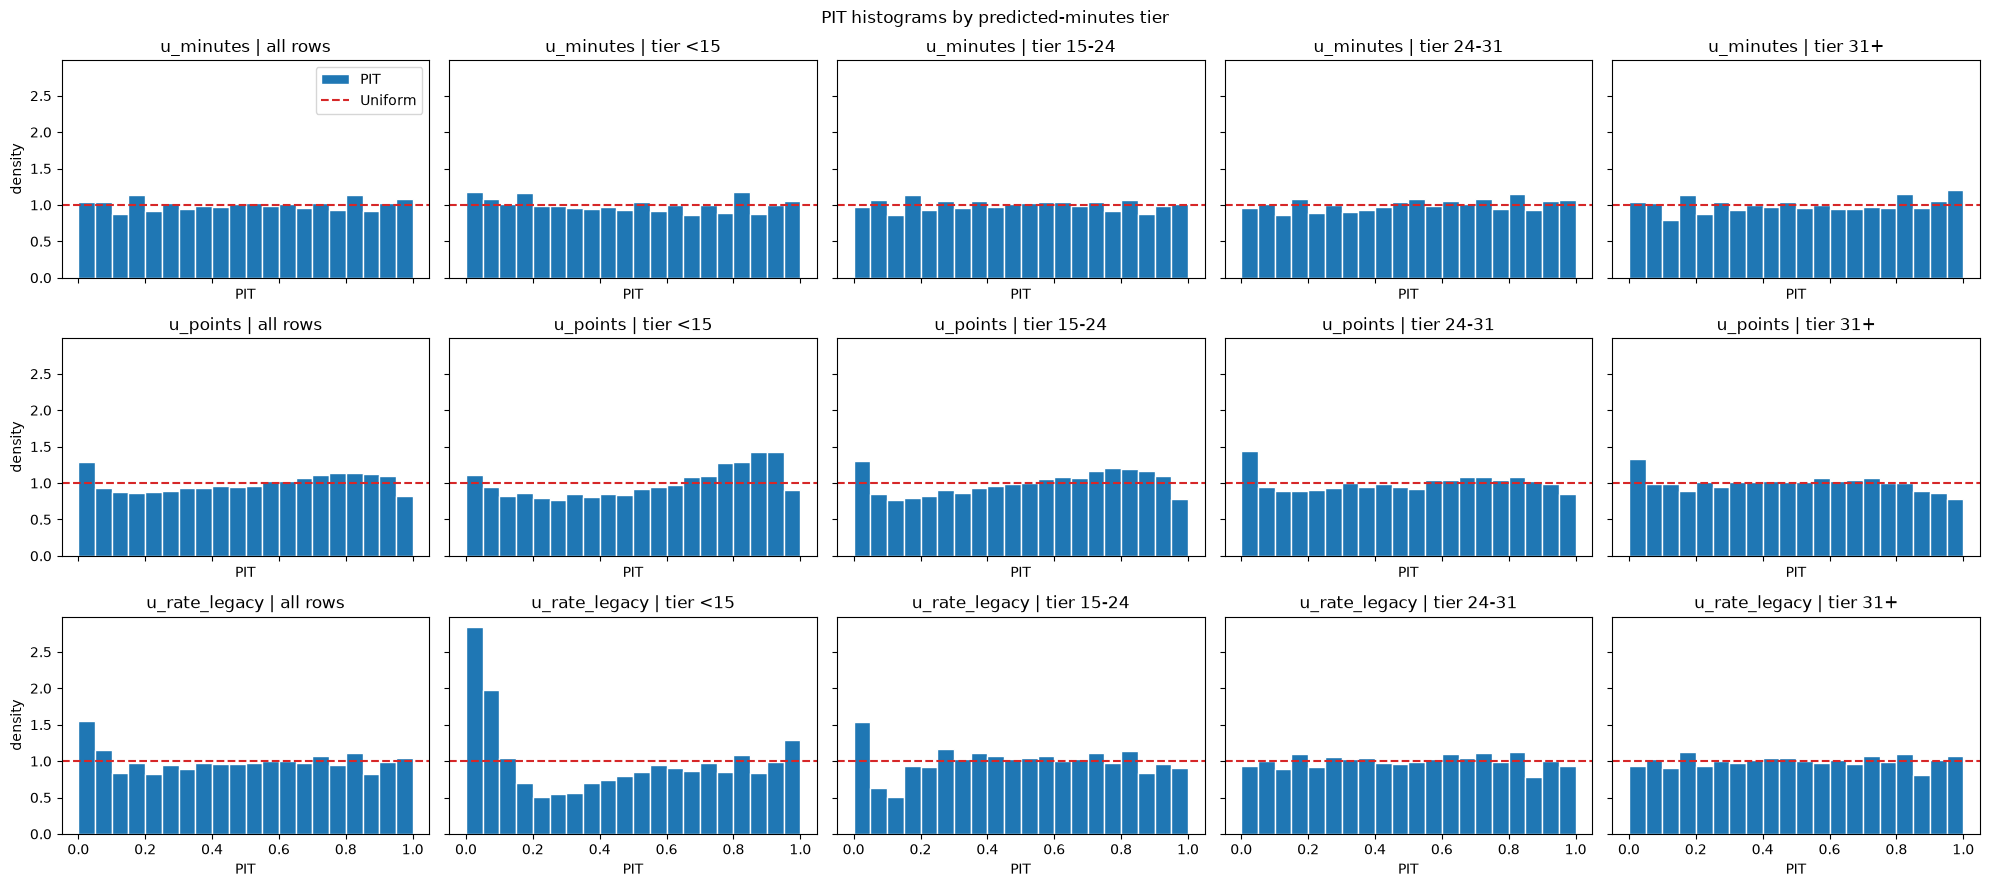

In [52]:
def pit_row(values: np.ndarray) -> dict:
    x = np.asarray(values, dtype=float)
    shares = np.histogram(x, bins=10, range=(0, 1))[0] / len(x)
    row = {
        "n": len(x),
        "mean": x.mean(),
        "12*var": 12 * x.var(ddof=1),
        "below_0.05": np.mean(x < 0.05),
        "above_0.95": np.mean(x > 0.95),
        "max_decile_gap": np.max(np.abs(shares - 0.1)),
    }
    row["flat"] = bool(
        abs(row["mean"] - 0.5) <= PIT_MEAN_TOLERANCE
        and abs(row["12*var"] - 1.0) <= PIT_VAR_SCALE_TOLERANCE
        and abs(row["below_0.05"] - 0.05) <= PIT_TAIL_TOLERANCE
        and abs(row["above_0.95"] - 0.05) <= PIT_TAIL_TOLERANCE
    )
    return row


pit_records = []
for column in ("u_minutes", "u_points", "u_rate_legacy"):
    pit_records.append({"pit": column, "slice": "all", **pit_row(rows[column])})
    for tier in TIERS:
        pit_records.append({"pit": column, "slice": f"tier {tier}", **pit_row(rows.loc[rows["tier"] == tier, column])})
for bucket, block in rows.groupby("minutes_bucket", sort=False):
    pit_records.append({"pit": "u_points", "slice": f"actual min {bucket}", **pit_row(block["u_points"])})
pit_table = pd.DataFrame(pit_records)
display(pit_table.round(3))

fig, axes = plt.subplots(3, 5, figsize=(20, 9), sharex=True, sharey=True)
for r, column in enumerate(("u_minutes", "u_points", "u_rate_legacy")):
    for c, label in enumerate(["all", *TIERS]):
        values = rows[column] if label == "all" else rows.loc[rows["tier"] == label, column]
        ax = axes[r, c]
        ax.hist(values, bins=HIST_BINS, range=(0, 1), density=True, color=OTHER_COLOR,
                edgecolor="white", label="PIT")
        ax.axhline(1.0, color=WINNER_COLOR, ls="--", label="Uniform")
        ax.set_title(f"{column} | {'all rows' if label == 'all' else 'tier ' + label}")
        ax.set_xlabel("PIT")
        if c == 0:
            ax.set_ylabel("density")
axes[0, 0].legend()
fig.suptitle("PIT histograms by predicted-minutes tier")
fig.tight_layout()
plt.show()

In [53]:
flat_minutes = pit_table.query("pit == 'u_minutes'")["flat"]
is_points = pit_table["pit"].eq("u_points")
flat_points = pit_table.loc[is_points & ~pit_table["slice"].str.startswith("actual"), "flat"]
not_flat = pit_table.loc[~pit_table["flat"] & pit_table["pit"].ne("u_rate_legacy"), ["pit", "slice"]]
print(f"u_minutes flat in {int(flat_minutes.sum())}/{len(flat_minutes)} slices")
print(f"u_points flat in {int(flat_points.sum())}/{len(flat_points)} overall/tier slices")
if len(not_flat):
    print("Slices outside tolerance (read their dependence with care):")
    print(not_flat.to_string(index=False))

u_minutes flat in 4/5 slices
u_points flat in 0/5 overall/tier slices
Slices outside tolerance (read their dependence with care):
      pit               slice
u_minutes            tier 31+
 u_points                 all
 u_points            tier <15
 u_points          tier 15-24
 u_points          tier 24-31
 u_points            tier 31+
 u_points actual min (20, 30]
 u_points  actual min (5, 10]
 u_points actual min (10, 20]
 u_points   actual min (0, 5]
 u_points actual min (40, 70]


In [54]:
# Randomized PITs can land exactly on 0 or 1 at a sampler atom; copula densities need (0, 1).
n_clipped = int(((rows[["u_minutes", "u_points"]] <= 0) | (rows[["u_minutes", "u_points"]] >= 1)).sum().sum())
for column in ("u_minutes", "u_points", "u_rate_legacy"):
    rows[column] = rows[column].clip(PIT_CLIP, 1 - PIT_CLIP)
print(f"PIT values clipped to [{PIT_CLIP}, 1 - {PIT_CLIP}]: {n_clipped}")
pairs_out = rows[["player_id", "game_id", "window_id", "u_minutes", "u_points", "u_rate_legacy"]]
pairs_out.to_parquet(RANK_PAIRS_FILE, index=False)
uv = rows[["u_minutes", "u_points"]].to_numpy(dtype=float)
assert np.isfinite(uv).all() and ((uv > 0) & (uv < 1)).all()
print(f"Saved {len(pairs_out):,} pairs to {RANK_PAIRS_FILE.relative_to(ROOT)}")

PIT values clipped to [1e-06, 1 - 1e-06]: 5
Saved 75,710 pairs to artifacts/nba/copula/rank_pairs.parquet


### 3. Dependence Diagnostics
The 10% corners cannot tell weak tail dependence from none, and pooling can hide offsetting effects, so all four corners are shown down to 1%, then split by tier, spread, and season.

In [55]:
def dependence_summary(a, b) -> dict:
    out = {
        "n": len(a),
        "kendall": stats.kendalltau(a, b).statistic,
        "spearman": stats.spearmanr(a, b).statistic,
    }
    for row in corner_lifts(a, b, [DIAG_Q]):
        out[f"lift_{row['corner']}"] = row["lift"]
    return out


overall = pd.DataFrame([
    {"pair": "u_minutes x u_points", **dependence_summary(rows["u_minutes"], rows["u_points"])},
    {"pair": "u_minutes x u_rate_legacy", **dependence_summary(rows["u_minutes"], rows["u_rate_legacy"])},
])
print(f"All pre-holdout pairs, lifts at q = {DIAG_Q}")
display(overall.round(3))

empirical_tails = pd.DataFrame(corner_lifts(rows["u_minutes"], rows["u_points"], TAIL_LEVELS))
empirical_tails["lift_ci_low"] = (empirical_tails["count"] - 1.96 * np.sqrt(empirical_tails["count"])) / empirical_tails["expected_indep"]
empirical_tails["lift_ci_high"] = (empirical_tails["count"] + 1.96 * np.sqrt(empirical_tails["count"])) / empirical_tails["expected_indep"]
legacy_tails = pd.DataFrame(corner_lifts(rows["u_minutes"], rows["u_rate_legacy"], TAIL_LEVELS))
tail_view = empirical_tails.pivot(index="q", columns="corner", values="lift")[CORNERS]
tail_view.columns = [f"{c} lift" for c in CORNERS]
tail_counts = empirical_tails.pivot(index="q", columns="corner", values="count")[["low_u_low_v", "high_u_high_v"]]
tail_counts.columns = ["low_u_low_v count", "high_u_high_v count"]
tail_view = tail_view.join(tail_counts)
tail_view["expected_indep"] = empirical_tails.groupby("q")["expected_indep"].first()
tail_view["legacy low_u_low_v lift"] = legacy_tails.loc[legacy_tails["corner"] == "low_u_low_v"].set_index("q")["lift"]
print("Joint exceedance lift over independence, u_minutes x u_points (legacy rate PIT for reference)")
display(tail_view.sort_index(ascending=False).round(2))

All pre-holdout pairs, lifts at q = 0.1


,pair,n,kendall,spearman,lift_low_u_low_v,lift_low_u_high_v,lift_high_u_low_v,lift_high_u_high_v
0,u_minutes x u_points,75710,0.071,0.106,1.572,0.770,0.864,1.33
1,u_minutes x u_rate_legacy,75710,0.142,0.211,3.749,1.102,0.370,1.02


Joint exceedance lift over independence, u_minutes x u_points (legacy rate PIT for reference)


,low_u_low_v lift,low_u_high_v lift,high_u_low_v lift,high_u_high_v lift,low_u_low_v count,high_u_high_v count,expected_indep,legacy low_u_low_v lift
q,,,,,,,,
0.10,1.57,0.77,0.86,1.33,1190,1007,757.10,3.75
0.05,1.83,0.68,1.01,1.45,347,275,189.28,6.11
0.02,1.92,0.66,1.29,1.58,58,48,30.28,10.50
0.01,1.32,1.19,0.79,1.85,10,14,7.57,15.19


,split,segment,pair,n,kendall,spearman,lift_low_u_low_v,lift_low_u_high_v,lift_high_u_low_v,lift_high_u_high_v
0,tier,15-24,points,19430,0.109,0.162,1.652,0.530,0.664,1.580
1,tier,15-24,legacy rate,19430,0.168,0.247,4.020,0.926,0.180,1.107
2,tier,24-31,points,18171,0.075,0.111,1.695,0.589,0.963,1.354
3,tier,24-31,legacy rate,18171,0.111,0.165,2.317,0.886,0.402,1.189
4,tier,31+,points,19646,0.023,0.034,1.614,0.713,1.206,0.911
5,tier,31+,legacy rate,19646,0.055,0.082,2.184,1.099,0.662,1.013
6,tier,<15,points,18463,0.080,0.121,1.322,1.262,0.612,1.489
7,tier,<15,legacy rate,18463,0.216,0.323,6.537,1.500,0.227,0.769
8,spread_bucket,close,points,40110,0.075,0.113,1.685,0.701,0.893,1.326
9,spread_bucket,close,legacy rate,40110,0.149,0.221,3.989,1.052,0.384,1.017


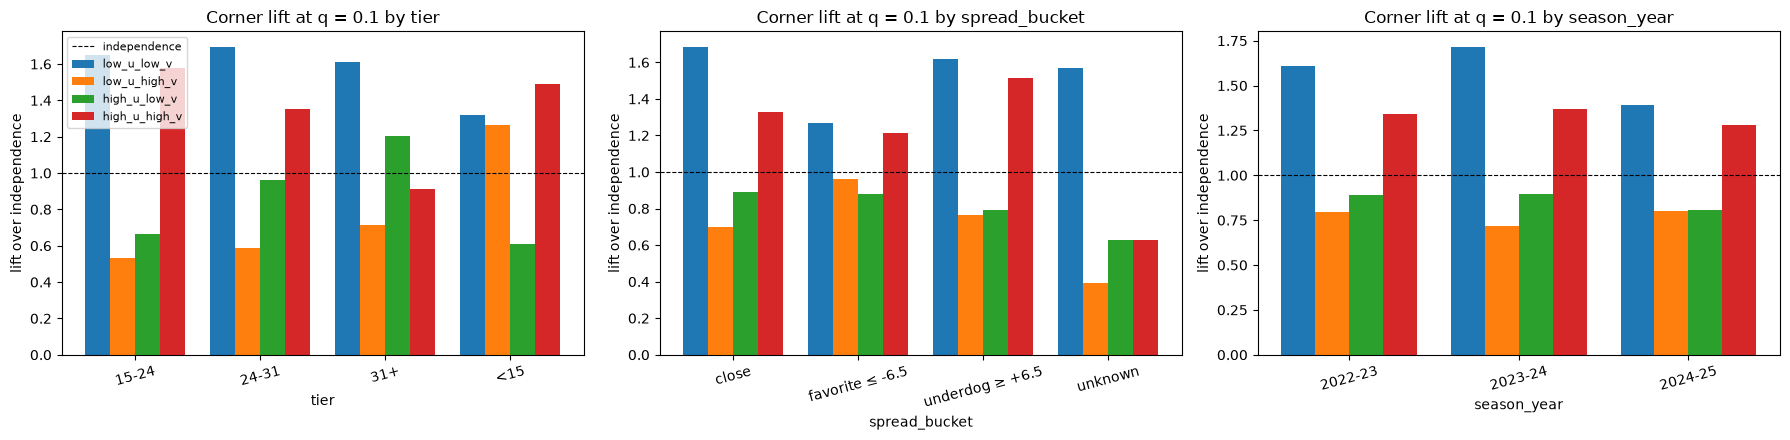

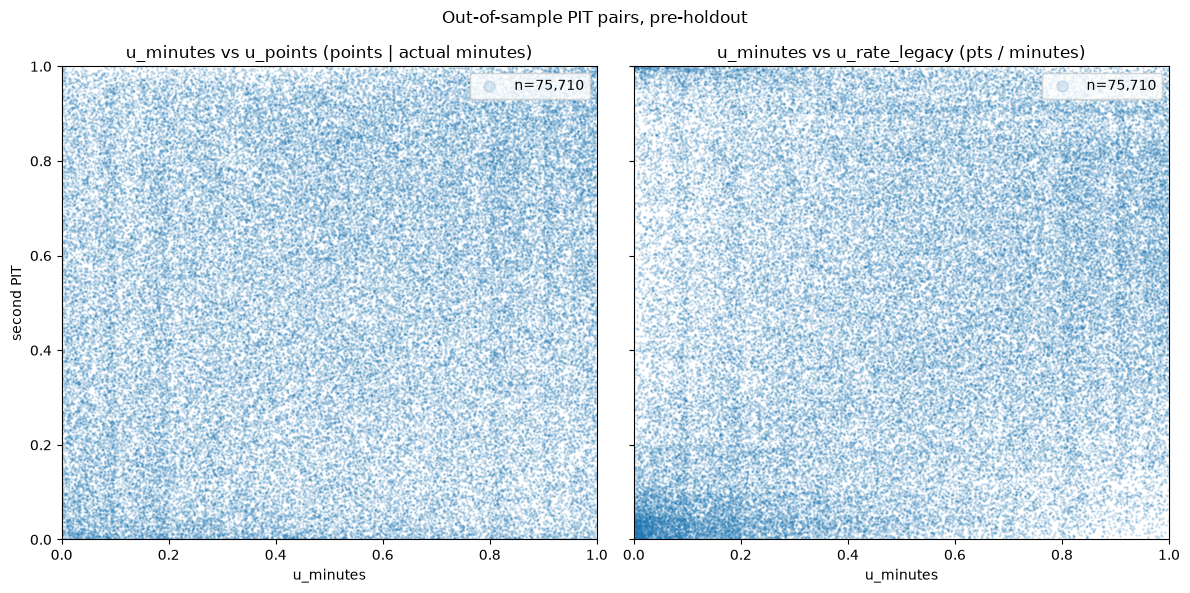

In [56]:
segment_records = []
for dimension in ("tier", "spread_bucket", "season_year"):
    for value, block in rows.groupby(dimension, sort=True):
        for pair_name, column in (("points", "u_points"), ("legacy rate", "u_rate_legacy")):
            segment_records.append({
                "split": dimension,
                "segment": value,
                "pair": pair_name,
                **dependence_summary(block["u_minutes"], block[column]),
            })
segments = pd.DataFrame(segment_records)
display(segments.round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, dimension in zip(axes, ("tier", "spread_bucket", "season_year")):
    view = segments.loc[(segments["split"] == dimension) & (segments["pair"] == "points")].set_index("segment")
    x = np.arange(len(view))
    width = 0.2
    for i, corner in enumerate(CORNERS):
        ax.bar(x + (i - 1.5) * width, view[f"lift_{corner}"], width, label=corner)
    ax.axhline(1.0, color="black", lw=0.8, ls="--", label="independence")
    ax.set_xticks(x)
    ax.set_xticklabels(view.index, rotation=15)
    ax.set_title(f"Corner lift at q = {DIAG_Q} by {dimension}")
    ax.set_xlabel(dimension)
    ax.set_ylabel("lift over independence")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for ax, (column, title) in zip(axes, (("u_points", "u_points (points | actual minutes)"),
                                      ("u_rate_legacy", "u_rate_legacy (pts / minutes)"))):
    ax.scatter(rows["u_minutes"], rows[column], s=SCATTER_SIZE, alpha=SCATTER_ALPHA,
               color=OTHER_COLOR, rasterized=True, label=f"n={len(rows):,}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("u_minutes")
    ax.set_title(f"u_minutes vs {title}")
    ax.legend(loc="upper right", markerscale=8)
axes[0].set_ylabel("second PIT")
fig.suptitle("Out-of-sample PIT pairs, pre-holdout")
fig.tight_layout()
plt.show()

### 4. Fits
Each family puts tail dependence in a different place, so the full set is fit with every rotation by MLE. The tau-inversion estimate sits next to MLE for the one-parameter families, and a game-level bootstrap gives intervals that respect teammates sharing a game.

AIC and BIC only add information when parameter counts differ. Here they do (Student-t, BB1, and BB7 have two parameters).

In [57]:
def fit_bicop(data, family_name: str, rotation: int, method: str = "mle"):
    bicop = pv.Bicop(family=FAMILIES[family_name], rotation=rotation)
    bicop.fit(data, controls=pv.FitControlsBicop(family_set=[FAMILIES[family_name]], parametric_method=method))
    return bicop


def rotations_for(family_name: str) -> list[int]:
    # Elliptical and Frank copulas carry the sign in the parameter; pyvinecopulib only allows rotation 0.
    return [0] if family_name in RADIALLY_SYMMETRIC else [0, 90, 180, 270]


def label_of(family_name: str, rotation: int) -> str:
    if family_name == "gumbel" and rotation == 180:
        return "gumbel 180 (survival)"
    return f"{family_name} {rotation}"


fit_records = []
fitted = {}
for family_name in FAMILIES:
    for rotation in rotations_for(family_name):
        bicop = fit_bicop(uv, family_name, rotation)
        params = bicop.parameters.ravel()
        try:
            itau = fit_bicop(uv, family_name, rotation, method="itau").parameters.ravel()
            itau_text = ", ".join(f"{p:.4f}" for p in itau) if bicop.npars == 1 else "n/a (2 params)"
        except Exception as error:
            itau_text = f"n/a ({str(error)[:40]})"
        label = label_of(family_name, rotation)
        fitted[label] = bicop
        fit_records.append({
            "model": label,
            "family": family_name,
            "rotation": rotation,
            "npars": int(bicop.npars),
            "params_mle": ", ".join(f"{p:.4f}" for p in params),
            "params_itau": itau_text,
            "tau": bicop.tau,
            "loglik": bicop.loglik(uv),
            "aic": bicop.aic(uv),
            "bic": bicop.bic(uv),
        })
comparison = pd.DataFrame(fit_records).sort_values(SELECTION_CRITERION).reset_index(drop=True)
comparison["rank"] = np.arange(1, len(comparison) + 1)
comparison["delta_aic"] = comparison["aic"] - comparison["aic"].min()

auto = pv.Bicop.from_data(uv, controls=SELECTION_CONTROLS)
best_label = comparison.loc[0, "model"]
selected = fitted[best_label]
assert abs(auto.aic(uv) - selected.aic(uv)) < 1e-3, f"pyvinecopulib picked {auto}, table picked {best_label}"
comparison.to_csv(COMPARISON_FILE, index=False)
print(f"Empirical Kendall tau: {stats.kendalltau(uv[:, 0], uv[:, 1]).statistic:+.4f}  n={len(uv):,}")
print(f"pyvinecopulib selection ({SELECTION_CRITERION}): {str(auto)}")
display(comparison[["rank", "model", "npars", "params_mle", "params_itau", "tau", "loglik", "aic", "bic", "delta_aic"]].round(3))

Empirical Kendall tau: +0.0708  n=75,710
pyvinecopulib selection (aic): <pyvinecopulib.core.Bicop> Bivariate copula: 
  family = Frank
  rotation = 0
  var_types = c,c
  parameters = 0.64



,rank,model,npars,params_mle,params_itau,tau,loglik,aic,bic,delta_aic
0,1,frank 0,1,0.6378,0.6399,0.071,435.763,-869.527,-860.292,0.000
1,2,student 0,2,"0.1016, 49.9996",n/a (2 params),0.065,412.057,-820.113,-801.644,49.414
2,3,gaussian 0,1,0.1003,0.1110,0.064,410.107,-818.215,-808.980,51.312
3,4,bb1 0,2,"0.0412, 1.0398",n/a (itau method is not available for this fa),0.058,380.429,-756.859,-738.389,112.668
4,5,bb7 0,2,"1.0413, 0.0635",n/a (itau method is not available for this fa),0.053,352.743,-701.487,-683.018,168.040
5,6,gumbel 0,1,1.0577,1.0762,0.055,335.492,-668.984,-659.749,200.543
6,7,bb1 180,2,"0.0754, 1.0206",n/a (itau method is not available for this fa),0.056,335.574,-667.148,-648.679,202.379
7,8,bb7 180,2,"1.0176, 0.0914",n/a (itau method is not available for this fa),0.053,317.084,-630.167,-611.698,239.360
8,9,clayton 180,1,0.1028,0.1524,0.049,292.275,-582.549,-573.315,286.978
9,10,clayton 0,1,0.0810,0.1524,0.039,262.887,-523.773,-514.538,345.754


#### Fitted vs empirical tail lift, all four corners
Each family's best rotation is compared with the empirical lift at 10%, 5%, 2%, and 1%. A family only holds up if it matches the diagonal corners *and* the off-diagonal ones. The bands are ±1.96·√count.

model               empirical  frank 0  student 0  gaussian 0  clayton 0  \
corner        q                                                            
high_u_high_v 0.01       1.85     1.34       2.55        1.93       1.08   
              0.02       1.58     1.34       2.07        1.72       1.08   
              0.05       1.45     1.31       1.63        1.49       1.08   
              0.10       1.33     1.27       1.39        1.33       1.07   
high_u_low_v  0.01       0.79     0.72       0.72        0.46       0.69   
              0.02       1.29     0.72       0.70        0.53       0.73   
              0.05       1.01     0.74       0.72        0.63       0.79   
              0.10       0.86     0.76       0.76        0.72       0.84   
low_u_high_v  0.01       1.19     0.72       0.72        0.46       0.69   
              0.02       0.66     0.72       0.70        0.53       0.73   
              0.05       0.68     0.74       0.72        0.63       0.79   
              0.10       0.77     0.76       0.76        0.72       0.84   
low_u_low_v   0.01       1.32     1.34       2.55        1.93       3.52   
              0.02       1.92     1.34       2.07        1.72       2.58   
              0.05       1.83     1.31       1.63        1.49       1.80   
              0.10       1.57     1.27       1.39        1.33       1.44   

model               gumbel 180 (survival)  
corner        q                            
high_u_high_v 0.01                   1.29  
              0.02                   1.25  
              0.05                   1.18  
              0.10                   1.14  
high_u_low_v  0.01                   0.74  
              0.02                   0.77  
              0.05                   0.81  
              0.10                   0.85  
low_u_high_v  0.01                   0.74  
              0.02                   0.77  
              0.05                   0.81  
              0.10                   0.85  
low_u_low_v   0.01                   6.52  
              0.02                   3.72  
              0.05                   2.04  
              0.10                   1.48

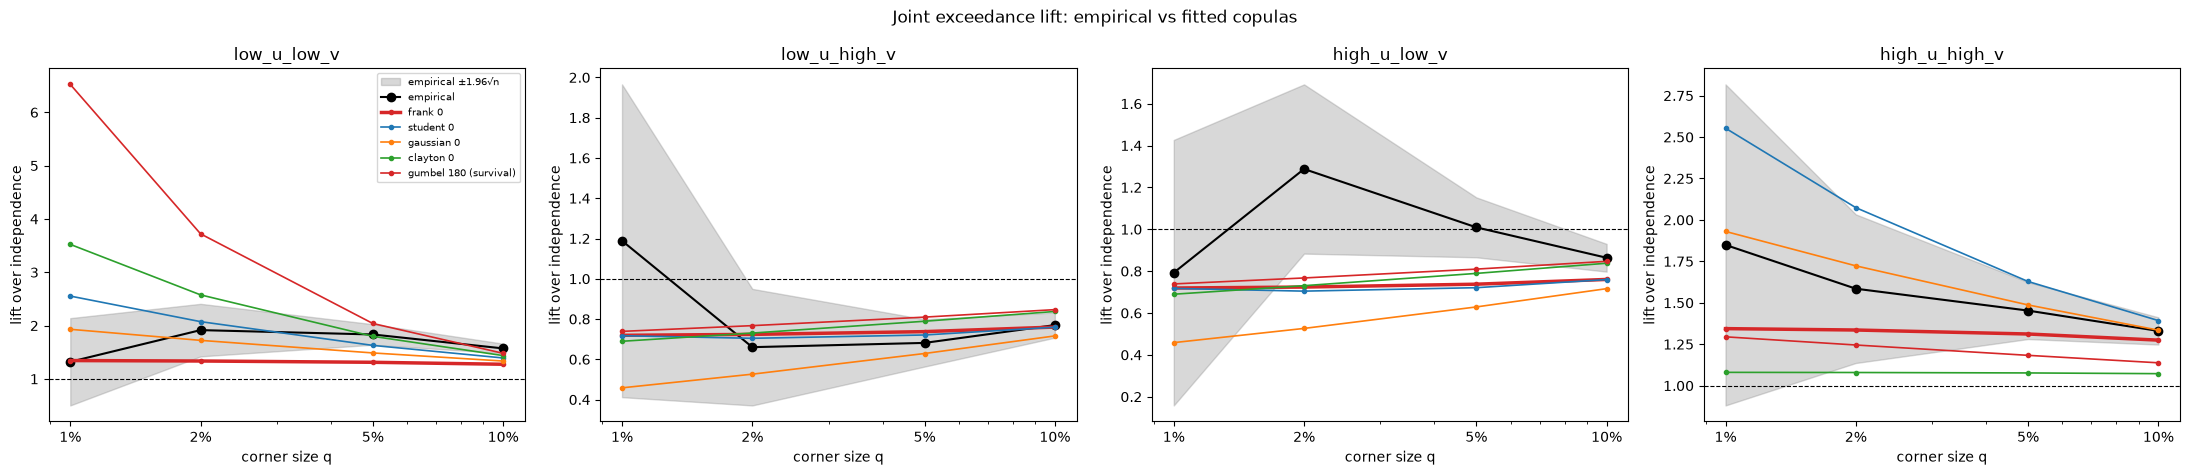

In [58]:
best_per_family = comparison.sort_values("aic").drop_duplicates("family")
top_models = best_per_family["model"].head(N_TOP_FAMILIES).tolist()
lift_models = list(dict.fromkeys(top_models + ["clayton 0", "gaussian 0", "gumbel 180 (survival)"]))
fitted_lifts = pd.concat(
    [pd.DataFrame(copula_corner_lifts(fitted[m], TAIL_LEVELS)).assign(model=m) for m in lift_models],
    ignore_index=True,
)
lift_table = pd.concat([
    empirical_tails[["q", "corner", "lift"]].assign(model="empirical"),
    fitted_lifts,
]).pivot_table(index=["corner", "q"], columns="model", values="lift")[["empirical", *lift_models]]
display(lift_table.round(2))

fig, axes = plt.subplots(1, 4, figsize=(22, 4.8), sharex=True)
for ax, corner in zip(axes, CORNERS):
    emp = empirical_tails.loc[empirical_tails["corner"] == corner].sort_values("q")
    ax.fill_between(emp["q"], emp["lift_ci_low"], emp["lift_ci_high"], color="grey", alpha=0.3, label="empirical ±1.96√n")
    ax.plot(emp["q"], emp["lift"], "ko-", label="empirical")
    for m in lift_models:
        fit_rows = fitted_lifts.loc[fitted_lifts["corner"] == corner].query("model == @m").sort_values("q")
        ax.plot(fit_rows["q"], fit_rows["lift"], marker=".",
                color=WINNER_COLOR if m == best_label else None, lw=2.5 if m == best_label else 1.2, label=m)
    ax.axhline(1.0, color="black", lw=0.8, ls="--")
    ax.set_xscale("log")
    ax.set_xticks(TAIL_LEVELS)
    ax.set_xticklabels([f"{q:.0%}" for q in TAIL_LEVELS])
    ax.set_title(corner)
    ax.set_xlabel("corner size q")
    ax.set_ylabel("lift over independence")
axes[0].legend(fontsize=7)
fig.suptitle("Joint exceedance lift: empirical vs fitted copulas")
fig.tight_layout()
plt.show()

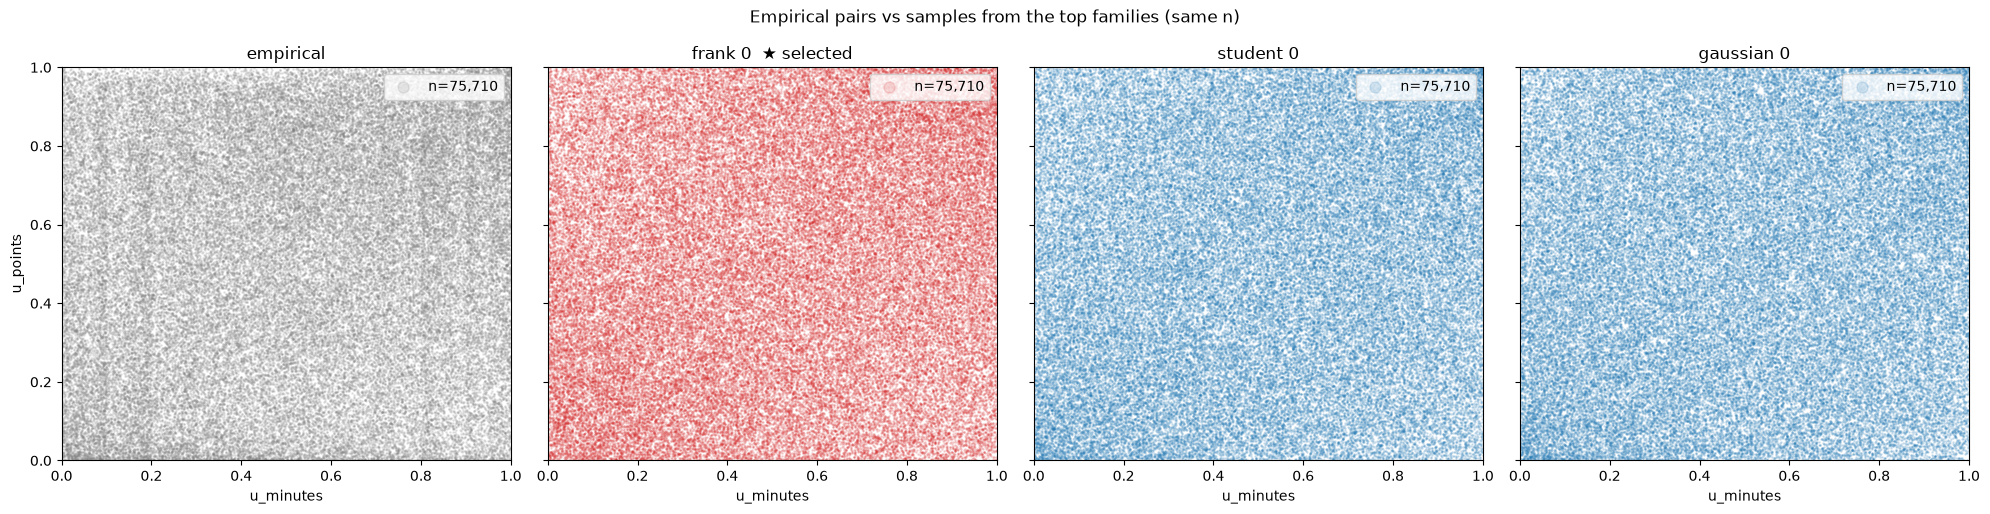

In [59]:
fig, axes = plt.subplots(1, N_TOP_FAMILIES + 1, figsize=(5 * (N_TOP_FAMILIES + 1), 5.2), sharex=True, sharey=True)
panels = [("empirical", uv, "C7")] + [
    (m, fitted[m].sample(len(uv), seeds=[SEED + i]), WINNER_COLOR if m == best_label else OTHER_COLOR)
    for i, m in enumerate(top_models)
]
for ax, (name, data, color) in zip(axes, panels):
    ax.scatter(data[:, 0], data[:, 1], s=SCATTER_SIZE, alpha=SCATTER_ALPHA, color=color,
               rasterized=True, label=f"n={len(data):,}")
    ax.set_title(name + ("  ★ selected" if name == best_label else ""))
    ax.set_xlabel("u_minutes")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="upper right", markerscale=8)
axes[0].set_ylabel("u_points")
fig.suptitle("Empirical pairs vs samples from the top families (same n)")
fig.tight_layout()
plt.show()

#### Selected family by segment
A pooled copula averages segments that can pull in opposite directions (for example, favourites' starters resting in blowout wins and underdogs' starters resting in blowout losses). Each segment is reselected over the full family set and compared with the pooled fit on the same rows.

In [60]:
segment_fit_records = []
for dimension in ("tier", "spread_bucket"):
    for value, block in rows.groupby(dimension, sort=True):
        data = block[["u_minutes", "u_points"]].to_numpy(dtype=float)
        local = pv.Bicop.from_data(data, controls=SELECTION_CONTROLS)
        segment_fit_records.append({
            "split": dimension,
            "segment": value,
            "n": len(block),
            "selected": f"{local.family_name} {local.rotation}",
            "params": ", ".join(f"{p:.3f}" for p in local.parameters.ravel()),
            "tau": local.tau,
        })
segment_fits = pd.DataFrame(segment_fit_records)
display(segment_fits.round(3))

,split,segment,n,selected,params,tau
0,tier,15-24,19430,Frank 0,0.996,0.110
1,tier,24-31,18171,Student 0,"0.108, 48.446",0.069
2,tier,31+,19646,Clayton 0,0.045,0.022
3,tier,<15,18463,Frank 0,0.701,0.078
4,spread_bucket,close,40110,Frank 0,0.674,0.075
5,spread_bucket,favorite ≤ -6.5,17573,Frank 0,0.380,0.042
6,spread_bucket,underdog ≥ +6.5,16753,Frank 0,0.845,0.093
7,spread_bucket,unknown,1274,Gumbel 0,1.040,0.039


### 5. Selection
In-sample likelihood rewards flexibility, and the question that matters is whether the copula improves points forecasts. So everything is refit on earlier windows and scored on the next one (four rolling folds; window 5, trained on 1-4, is the headline). That covers the count model, the copula candidates, and the direct model. 2025-26 is still untouched.

**- (a) Independent:** `U` → minutes, then points ~ NB given those minutes (same mean and dispersion model as Section 2, refit on the fold's training windows), with `V` independent of `U`.

**- (b) Copula:** same, with `V | U` drawn from the copula selected on the fold's training windows.

**- (c) Direct:** the same NB, plus `gamma * Phi^-1(U)` in `log mu`. The minutes surprise is a feature, and there is no copula. If (c) wins, the copula is unnecessary.

PMFs are exact in `V` and integrate `U` over a midpoint grid of `MINUTES_GRID` points, so there is no Monte Carlo noise in the comparison.

In [61]:
def game_bootstrap(diff: np.ndarray, games: np.ndarray, n_boot: int, seed: int) -> tuple[float, float, float]:
    finite = np.isfinite(diff)
    codes, _ = pd.factorize(games[finite])
    sums = np.bincount(codes, weights=diff[finite])
    counts = np.bincount(codes).astype(float)
    draws = np.random.default_rng(seed).integers(0, len(sums), size=(n_boot, len(sums)))
    boot = sums[draws].sum(axis=1) / counts[draws].sum(axis=1)
    low, high = np.quantile(boot, [0.025, 0.975])
    return float(diff[finite].mean()), float(low), float(high)

In [62]:
def line_probabilities(pmf, lines):
    cdf = np.cumsum(pmf, axis=1)
    rows_ix = np.arange(len(lines))
    floor_k = np.clip(np.floor(lines).astype(int), 0, pmf.shape[1] - 1)
    p_over = 1.0 - cdf[rows_ix, floor_k]
    p_push = np.where(lines == np.floor(lines), pmf[rows_ix, floor_k], 0.0)
    return p_over, p_push


def score_pmfs(pmfs: dict, test: pd.DataFrame) -> dict:
    y = test["pts"].to_numpy(dtype=float)
    pit_atom = seeded_unit_uniform(test["player_id"], test["game_id"], seed=SEED, label="backtest_pit")
    lines_pseudo = pseudo_lines(test["pts_ewm"])
    line_sets = {name: lines_pseudo[:, i] for i, name in enumerate(PSEUDO_LINE_NAMES)}
    line_sets.update({f"fixed {line}": np.full(len(test), line) for line in FIXED_LINES})
    row_scores = {}
    for name, pmf in pmfs.items():
        scores = {
            "log_score": integer_log_score(pmf, y),
            "rps": rps(pmf, y),
            "pit": pmf_randomized_pit(pmf, y, pit_atom),
        }
        for line_name, lines in line_sets.items():
            settled = np.isfinite(lines) & (y != lines)
            p_over, p_push = line_probabilities(pmf[settled], lines[settled])
            brier = np.full(len(test), np.nan)
            brier[settled] = binary_brier(p_over / (1 - p_push), y[settled] > lines[settled])
            scores[f"brier {line_name}"] = brier
        row_scores[name] = scores
    return row_scores

In [63]:
u_grid = (np.arange(MINUTES_GRID) + 0.5) / MINUTES_GRID


def predictive_pmfs(test: pd.DataFrame, setups: dict, starting) -> dict:
    frame = test.assign(starting=np.asarray(starting, dtype=int))
    rate_hat, rate_cv = rate_moments(frame)
    lower, upper = minutes_groups(frame["starting"], minutes_tables)
    minutes_at_u = minutes_ppf(
        np.tile(u_grid, (len(frame), 1)), frame[MINUTES_KNOTS].to_numpy(dtype=float), lower, upper, minutes_tables
    )
    pmfs = {name: np.zeros((len(frame), KMAX + 1)) for name in setups}
    for start in range(0, len(frame), PMF_BATCH_ROWS):
        block = slice(start, start + PMF_BATCH_ROWS)
        for name, kwargs in setups.items():
            pmfs[name][block] = conditional_points_pmf(
                minutes_at_u[block], u_grid, rate_hat[block], kmax=KMAX, rate_cv=rate_cv[block], **kwargs
            )
    return pmfs


def run_fold(train_windows, test_window) -> dict:
    train = rows.loc[rows["window_id"].isin(train_windows)].reset_index(drop=True)
    test = rows.loc[rows["window_id"].eq(test_window)].reset_index(drop=True)
    assert train["game_date"].max() < test["game_date"].min()

    count_tr = fit_count_model(train["minutes"], train["pts"], train["rate_hat"], rate_cv=train["rate_cv"])
    for frame in (train, test):
        frame["u_points_tr"] = count_pit(
            frame["pts"],
            count_tr.mean(frame["minutes"], frame["rate_hat"]),
            count_tr.alpha(frame["minutes"], frame["rate_cv"]),
            frame["points_atom"],
        ).clip(PIT_CLIP, 1 - PIT_CLIP)
    copula_tr = pv.Bicop.from_data(train[["u_minutes", "u_points_tr"]].to_numpy(dtype=float), controls=SELECTION_CONTROLS)
    direct_tr = fit_count_model(
        train["minutes"], train["pts"], train["rate_hat"], rate_cv=train["rate_cv"],
        surprise=stats.norm.ppf(train["u_minutes"]),
    )
    setups = {
        "a_independent": dict(model=count_tr),
        "b_copula": dict(model=count_tr, bicop=copula_tr),
        "c_direct": dict(model=direct_tr, use_surprise=True),
    }
    if LINEUPS_KNOWN:
        pmfs = predictive_pmfs(test, setups, test["starting"])
    else:
        p_start = test["start_rate"].to_numpy()[:, None]
        as_starter = predictive_pmfs(test, setups, np.ones(len(test)))
        as_bench = predictive_pmfs(test, setups, np.zeros(len(test)))
        pmfs = {name: p_start * as_starter[name] + (1 - p_start) * as_bench[name] for name in setups}
    for pmf in pmfs.values():
        assert np.allclose(pmf.sum(axis=1), 1.0)
    return dict(train=train, test=test, copula=copula_tr, count=count_tr, direct=direct_tr,
                pmfs=pmfs, row_scores=score_pmfs(pmfs, test))


needed = sorted({w for train_windows, test_window in ROLLING_FOLDS for w in (*train_windows, test_window)})
missing = sorted(set(needed) - set(rows["window_id"].unique()))
if missing:
    raise ValueError(
        f"OOS table has no rows for window(s) {missing}. "
        "Rerun the minutes and points notebooks, then scripts/build_oos_table.py --replace."
    )

fold_results = {test_window: run_fold(train_windows, test_window) for train_windows, test_window in ROLLING_FOLDS}

fold_records = []
pooled_parts = {}
for test_window, fold in fold_results.items():
    games = fold["test"]["game_key"].to_numpy()
    for left, right in COMPARISONS:
        diff = fold["row_scores"][right]["log_score"] - fold["row_scores"][left]["log_score"]
        pooled_parts.setdefault((left, right), []).append((diff, games))
        mean, low, high = game_bootstrap(diff, games, SCORE_BOOT_REPS, SEED)
        fold_records.append({"test_window": test_window, "comparison": f"{right} - {left}",
                             "mean_diff": mean, "ci_low": low, "ci_high": high})
for (left, right), parts in pooled_parts.items():
    diff = np.concatenate([d for d, _ in parts])
    games = np.concatenate([g for _, g in parts])
    mean, low, high = game_bootstrap(diff, games, SCORE_BOOT_REPS, SEED)
    fold_records.append({"test_window": "pooled", "comparison": f"{right} - {left}",
                         "mean_diff": mean, "ci_low": low, "ci_high": high})
fold_diffs = pd.DataFrame(fold_records)
print("Log score difference per player-game, by test window (higher favours the left-hand setup).")
display(fold_diffs.pivot(index="comparison", columns="test_window", values="mean_diff").round(5))
display(pd.Series(
    {w: label_of(FAMILY_NAMES[f["copula"].family], f["copula"].rotation) for w, f in fold_results.items()},
    name="copula picked on train",
).to_frame())

fold = fold_results[TEST_WINDOW]
train, test, copula_tr, count_tr, direct_tr = (fold[k] for k in ("train", "test", "copula", "count", "direct"))
pmfs, row_scores = fold["pmfs"], fold["row_scores"]
copula_tr_label = label_of(FAMILY_NAMES[copula_tr.family], copula_tr.rotation)
uv_tr = train[["u_minutes", "u_points_tr"]].to_numpy(dtype=float)
uv_te = test[["u_minutes", "u_points_tr"]].to_numpy(dtype=float)

pooled_log = {
    name: np.concatenate([f["row_scores"][name]["log_score"] for f in fold_results.values()]).mean()
    for name in pmfs
}
best_setup = max(pooled_log, key=pooled_log.get)

Log score difference per player-game, by test window (higher favours the left-hand setup).


test_window,2,3,4,5,pooled
comparison,,,,,
b_copula - a_independent,0.00546,0.00416,0.00521,0.00435,0.00479
c_direct - a_independent,0.00311,0.00227,0.00287,0.00224,0.00262
c_direct - b_copula,-0.00235,-0.00188,-0.00234,-0.00211,-0.00217


,copula picked on train
2,student 0
3,frank 0
4,frank 0
5,frank 0


#### Game-level bootstrap for the selected copula
The log-likelihood treats rows as independent, but teammates share a game. Whole games are resampled with replacement, and the selected family and rotation are refit each time.

frank 0: 200 game-level resamples of 3,558 games


,estimate,ci_low,ci_high,boot_se
param_1,0.6378,0.5993,0.6817,0.0220
tau,0.0706,0.0664,0.0754,0.0024


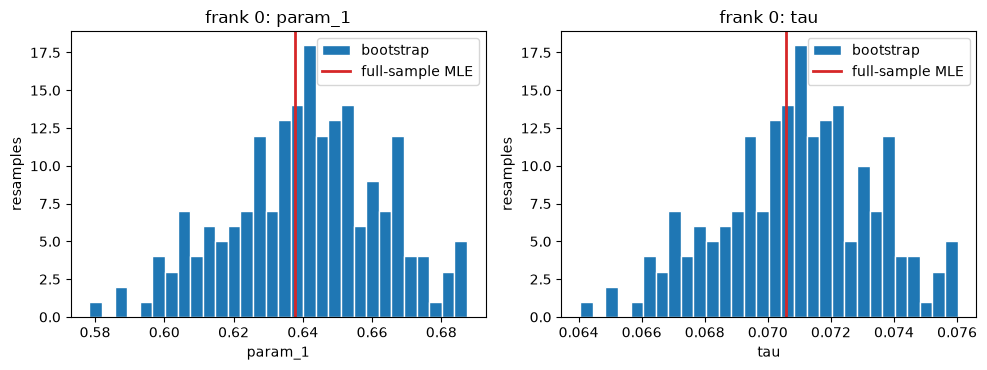

In [64]:
export_family = FAMILY_NAMES[copula_tr.family]
export_rotation = int(copula_tr.rotation)
export_label = label_of(export_family, export_rotation)
exported = fit_bicop(uv, export_family, export_rotation)
if export_label != best_label:
    lineage_warnings.append(
        f"In-sample AIC prefers {best_label}; the spec exports {export_label}, the family picked out of sample."
    )

game_codes, game_index = pd.factorize(rows["game_key"])
rows_by_game = list(pd.Series(np.arange(len(rows))).groupby(game_codes).indices.values())
boot_rng = np.random.default_rng(SEED)
boot_records = []
for _ in range(BOOT_REPS):
    drawn = boot_rng.integers(0, len(rows_by_game), size=len(rows_by_game))
    index = np.concatenate([rows_by_game[g] for g in drawn])
    refit = fit_bicop(uv[index], export_family, export_rotation)
    boot_records.append([*refit.parameters.ravel(), refit.tau])
param_names = [f"param_{i + 1}" for i in range(int(exported.npars))]
boot = pd.DataFrame(boot_records, columns=[*param_names, "tau"])
point = [*exported.parameters.ravel(), exported.tau]
boot_ci = pd.DataFrame({
    "estimate": point,
    "ci_low": boot.quantile(0.025).to_numpy(),
    "ci_high": boot.quantile(0.975).to_numpy(),
    "boot_se": boot.std().to_numpy(),
}, index=boot.columns)
print(f"{export_label}: {BOOT_REPS} game-level resamples of {len(rows_by_game):,} games")
display(boot_ci.round(4))

fig, axes = plt.subplots(1, len(boot.columns), figsize=(5 * len(boot.columns), 3.8))
for ax, column, est in zip(np.atleast_1d(axes), boot.columns, point):
    ax.hist(boot[column], bins=30, color=OTHER_COLOR, edgecolor="white", label="bootstrap")
    ax.axvline(est, color=WINNER_COLOR, lw=2, label="full-sample MLE")
    ax.set_title(f"{export_label}: {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("resamples")
    ax.legend()
fig.tight_layout()
plt.show()

In [65]:
oos_pit = pd.DataFrame(
    [{"test_window": w, "slice": "all", **pit_row(f["test"]["u_points_tr"])} for w, f in fold_results.items()]
    + [{"test_window": w, "slice": f"tier {t}", **pit_row(f["test"].loc[f["test"]["tier"] == t, "u_points_tr"])}
       for w, f in fold_results.items() for t in TIERS]
)
display(oos_pit.round(3))

,test_window,slice,n,mean,12*var,below_0.05,above_0.95,max_decile_gap,flat
0,2,all,14919,0.510,1.025,0.065,0.041,0.017,False
1,3,all,15346,0.501,1.026,0.070,0.039,0.018,False
2,4,all,15441,0.516,1.040,0.065,0.045,0.017,False
3,5,all,15267,0.520,1.029,0.061,0.049,0.016,False
4,2,tier <15,3664,0.538,1.046,0.053,0.044,0.034,False
5,2,tier 15-24,3738,0.516,1.004,0.070,0.037,0.026,False
6,2,tier 24-31,3595,0.501,1.049,0.073,0.049,0.021,False
7,2,tier 31+,3922,0.485,0.987,0.064,0.035,0.025,False
8,3,tier <15,3868,0.537,1.073,0.063,0.048,0.046,False
9,3,tier 15-24,3839,0.505,1.038,0.074,0.036,0.025,False


In [66]:
segment_oos_records = []
for dimension in ("tier", "spread_bucket"):
    for value in sorted(rows[dimension].unique()):
        for test_window, fold in fold_results.items():
            tr = fold["train"].loc[fold["train"][dimension] == value, ["u_minutes", "u_points_tr"]].to_numpy(dtype=float)
            te = fold["test"].loc[fold["test"][dimension] == value, ["u_minutes", "u_points_tr"]].to_numpy(dtype=float)
            if len(tr) < MIN_SEGMENT_TRAIN or len(te) == 0:
                continue
            local = pv.Bicop.from_data(tr, controls=SELECTION_CONTROLS)
            segment_oos_records.append({
                "split": dimension,
                "segment": value,
                "test_window": test_window,
                "n_test": len(te),
                "selected": label_of(FAMILY_NAMES[local.family], local.rotation),
                "test_gain_per_row": (local.loglik(te) - fold["copula"].loglik(te)) / len(te),
            })
segment_oos = pd.DataFrame(segment_oos_records)
print("Segment copula minus pooled train copula, test log density per row. Trust a segment only if every window is positive.")
display(segment_oos.pivot_table(index=["split", "segment"], columns="test_window", values="test_gain_per_row").round(4))

Segment copula minus pooled train copula, test log density per row. Trust a segment only if every window is positive.


test_window                         2       3       4       5
split         segment                                        
spread_bucket close            0.0001  0.0000  0.0000 -0.0000
              favorite ≤ -6.5 -0.0002  0.0018  0.0002  0.0003
              underdog ≥ +6.5 -0.0002  0.0016 -0.0001 -0.0002
              unknown             NaN     NaN  0.0065 -0.0013
tier          15-24            0.0014  0.0012  0.0007  0.0017
              24-31           -0.0002  0.0004 -0.0012  0.0004
              31+              0.0027  0.0028  0.0040  0.0032
              <15              0.0011  0.0002  0.0002 -0.0004

In [67]:
oos_records = []
for family_name, family in FAMILIES.items():
    bicop = pv.Bicop.from_data(
        uv_tr,
        controls=pv.FitControlsBicop(family_set=[family], parametric_method="mle",
                                     selection_criterion=SELECTION_CRITERION, preselect_families=False),
    )
    oos_records.append({
        "model": label_of(family_name, bicop.rotation),
        "npars": int(bicop.npars),
        "train_aic": bicop.aic(uv_tr),
        "test_mean_log_density": bicop.loglik(uv_te) / len(uv_te),
        "test_loglik": bicop.loglik(uv_te),
    })
oos_scores = pd.DataFrame(oos_records).sort_values("test_mean_log_density", ascending=False).reset_index(drop=True)
oos_scores["test_rank"] = np.arange(1, len(oos_scores) + 1)
oos_scores["train_rank"] = oos_scores["train_aic"].rank().astype(int)
print(f"Train windows {TRAIN_WINDOWS}: {len(train):,} rows | test window {TEST_WINDOW}: {len(test):,} rows")
print(f"Copula picked on train AIC: {copula_tr_label} ({str(copula_tr)})")
print("Independence scores 0 on mean log density.")
display(oos_scores.round(5))

display(pd.DataFrame({
    "count model (a, b)": count_tr.to_dict(),
    "direct model (c)": direct_tr.to_dict(),
}).round(4))

Train windows (1, 2, 3, 4): 60,443 rows | test window 5: 15,267 rows
Copula picked on train AIC: frank 0 (<pyvinecopulib.core.Bicop> Bivariate copula: 
  family = Frank
  rotation = 0
  var_types = c,c
  parameters = 0.64
)
Independence scores 0 on mean log density.


,model,npars,train_aic,test_mean_log_density,test_loglik,test_rank,train_rank
0,frank 0,1,-710.21117,0.00537,81.92890,1,1
1,gaussian 0,1,-676.63842,0.00482,73.62694,2,3
2,student 0,2,-681.65936,0.00472,72.02155,3,2
3,bb1 0,2,-629.54160,0.00431,65.84348,4,4
4,gumbel 0,1,-550.17849,0.00407,62.08667,5,6
5,bb7 0,2,-586.80855,0.00388,59.29771,6,5
6,clayton 180,1,-477.51423,0.00373,56.93070,7,7
7,joe 0,1,-343.60153,0.00270,41.18333,8,8


,"count model (a, b)",direct model (c)
log_kappa,-0.2487,0.0467
beta,1.0794,0.9880
log_alpha,-1.4870,-1.5581
beta2,-0.0022,-0.0450
alpha_minutes,-1.1675,-1.1992
alpha_cv,0.7836,0.7062
gamma,0.0000,0.0582
minutes_center,24.0000,24.0000


In [68]:
summary_records = []
for name, scores in row_scores.items():
    pit = scores["pit"]
    record = {
        "setup": name,
        "log_score": scores["log_score"].mean(),
        "rps": scores["rps"].mean(),
        "pit_below_0.05": np.mean(pit < 0.05),
        "pit_above_0.95": np.mean(pit > 0.95),
        "pit_below_0.01": np.mean(pit < 0.01),
        "pit_above_0.99": np.mean(pit > 0.99),
    }
    for key in scores:
        if key.startswith("brier "):
            record[key] = np.nanmean(scores[key])
    summary_records.append(record)
backtest = pd.DataFrame(summary_records).set_index("setup")
print(f"Window-{TEST_WINDOW} points backtest. Log score: higher is better. RPS and Brier: lower is better. Ideal PIT tails: 0.05 and 0.01.")
display(backtest.T.round(5))

Window-5 points backtest. Log score: higher is better. RPS and Brier: lower is better. Ideal PIT tails: 0.05 and 0.01.


setup,a_independent,b_copula,c_direct
log_score,-2.97004,-2.96569,-2.96780
rps,3.12344,3.12078,3.12153
pit_below_0.05,0.06491,0.06006,0.06203
pit_above_0.95,0.05541,0.04919,0.04913
pit_below_0.01,0.01985,0.01696,0.01847
pit_above_0.99,0.01166,0.00989,0.00950
brier L0-8,0.12426,0.12394,0.12464
brier L0-4,0.19373,0.19360,0.19398
brier L0,0.23443,0.23410,0.23405
brier L0+4,0.16816,0.16776,0.16776


,comparison,metric,better_if,mean_diff,ci_low,ci_high,significant
0,b_copula - a_independent,log_score,positive,0.004349,0.003285,0.005423,True
1,b_copula - a_independent,rps,negative,-0.002658,-0.003815,-0.001529,True
2,b_copula - a_independent,brier L0,negative,-0.000328,-0.000444,-0.000215,True
3,b_copula - a_independent,brier fixed 4.5,negative,-0.000036,-0.000157,0.000081,False
4,c_direct - a_independent,log_score,positive,0.002238,0.001063,0.003447,True
5,c_direct - a_independent,rps,negative,-0.001910,-0.004974,0.001216,False
6,c_direct - a_independent,brier L0,negative,-0.000380,-0.000704,-0.000062,True
7,c_direct - a_independent,brier fixed 4.5,negative,-0.000437,-0.000637,-0.000244,True
8,c_direct - b_copula,log_score,positive,-0.002112,-0.002980,-0.001228,True
9,c_direct - b_copula,rps,negative,0.000748,-0.002101,0.003640,False


setup,a_independent,b_copula,c_direct
tier,,,
<15,-2.2860,-2.2783,-2.2811
15-24,-2.9526,-2.9465,-2.9473
24-31,-3.2026,-3.1991,-3.2009
31+,-3.4053,-3.4052,-3.4085


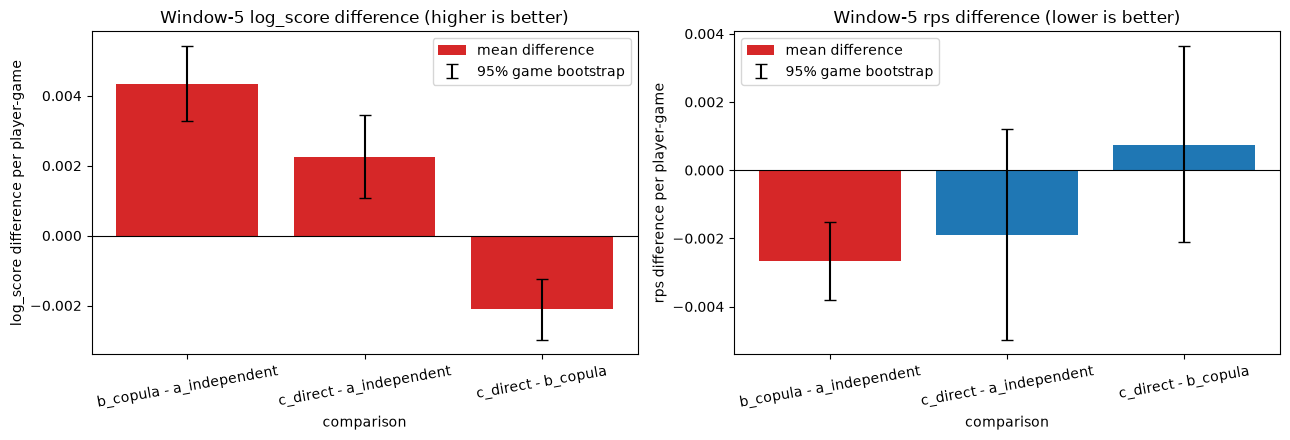

In [69]:
games_te = test["game_key"].to_numpy()
metrics_to_compare = {"log_score": +1, "rps": -1, "brier L0": -1, "brier fixed 4.5": -1}
diff_records = []
for left, right in (("a_independent", "b_copula"), ("a_independent", "c_direct"), ("b_copula", "c_direct")):
    for metric, sign in metrics_to_compare.items():
        diff = row_scores[right][metric] - row_scores[left][metric]
        mean, low, high = game_bootstrap(diff, games_te, SCORE_BOOT_REPS, SEED)
        diff_records.append({
            "comparison": f"{right} - {left}",
            "metric": metric,
            "better_if": "positive" if sign > 0 else "negative",
            "mean_diff": mean,
            "ci_low": low,
            "ci_high": high,
            "significant": (low > 0 or high < 0),
        })
diffs = pd.DataFrame(diff_records)
display(diffs.round(6))

tier_records = []
for tier in TIERS:
    mask = test["tier"].eq(tier).to_numpy()
    for name in pmfs:
        tier_records.append({"tier": tier, "setup": name, "n": int(mask.sum()),
                             "log_score": row_scores[name]["log_score"][mask].mean(),
                             "rps": row_scores[name]["rps"][mask].mean()})
display(pd.DataFrame(tier_records).pivot(index="tier", columns="setup", values="log_score").loc[TIERS].round(4))

backtest_out = backtest.reset_index()
backtest_out.to_csv(BACKTEST_FILE, index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric in zip(axes, ("log_score", "rps")):
    view = diffs.loc[diffs["metric"] == metric]
    colors = [WINNER_COLOR if s else OTHER_COLOR for s in view["significant"]]
    ax.bar(view["comparison"], view["mean_diff"], color=colors, label="mean difference")
    ax.errorbar(view["comparison"], view["mean_diff"],
                yerr=[view["mean_diff"] - view["ci_low"], view["ci_high"] - view["mean_diff"]],
                fmt="none", color="black", capsize=4, label="95% game bootstrap")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"Window-{TEST_WINDOW} {metric} difference ({'higher' if metric == 'log_score' else 'lower'} is better)")
    ax.set_xlabel("comparison")
    ax.set_ylabel(f"{metric} difference per player-game")
    ax.tick_params(axis="x", rotation=10)
    ax.legend()
fig.tight_layout()
plt.show()

#### Market comparison and betting simulation
Reads `data/backtest/singleBookies.csv` (2024-25 player props, one snapshot per book, no closing line). Points props run 2024-10-23 to 2025-04-12, so windows 4 and 5 are scored. Most of the volume (Feb–Apr) and nearly all multi-book lines are in window 5. `load_single_bookies` returns a consensus row per player-game and each book's own quote per player-game:

**- Matching:** names are normalized (accents, punctuation, Jr./II suffixes, `ODDS_NAME_ALIASES`) and matched to gamelogs on the same date, falling back to the day before because `GAME_DATE` is the UTC date.

**- Line:** the line quoted by the most books, ties broken toward the median line. Lines quoted by fewer than `ODDS_MIN_BOOKS` books are dropped. Single-book lines are more lopsided than multi-book ones (median |p_over - 0.5| of 0.031 against 0.010 at four or more books), but almost all of the window-4 overlap is single-book (1,658 of 1,746 matched rows), so the default is 1. Raising it to 2 leaves about 88 rows.

**- Prices:** `over_bet` / `under_bet` are the best price across books (line shopping). `over_close` / `under_close` are the median price across books and stand in for the close. So the log-loss comparison is against the de-vigged consensus, and `mean_edge_vs_consensus` is the edge of the shopped price over that consensus. It is not closing-line value, and on single-book lines it is just the negative vig.

**- By book:** each book keeps its own line (the one nearest the consensus line if it posts several) and its own prices. Its log loss is against that book's de-vigged price, so it shows how sharp each book is against the model. Bets use only that book's prices. `mean_edge_vs_consensus` is computed only on bets where the book's line equals the consensus line.

The best setup's PMF is scored against the de-vigged close on log loss, and a one-side-per-line bet is placed when its expected value at the bet price exceeds `EDGE_THRESHOLD`. Pick `EDGE_THRESHOLD` before looking at these results, and never tune it on windows 4-5 or on 2025-26. If you do, the ROI shown is the result of searching for it.

In [77]:
def model_over(fold: dict, m: pd.DataFrame) -> np.ndarray:
    """Best setup's over probability at m's lines, given no push."""
    p_over, p_push = line_probabilities(fold["pmfs"][best_setup][m["row"].to_numpy()], m["line"].to_numpy(dtype=float))
    return p_over / (1 - p_push)


if ODDS_PATH.exists():
    odds_logs = pd.concat(
        [pd.read_parquet(str(DATA_PATH).format(season=season), columns=["player_id", "player_name", "game_id", "game_date"])
         for season in PREHOLDOUT_SEASONS],
        ignore_index=True,
    )
    odds, book_odds = load_single_bookies(ODDS_PATH, odds_logs, min_books=ODDS_MIN_BOOKS, aliases=ODDS_NAME_ALIASES)
    print(f"Odds: matched {odds.attrs['match_rate']:.1%} of {odds.attrs['n_quotes']:,} two-sided book lines to gamelogs")
    for frame in (odds, book_odds):
        frame["game_key"] = frame["game_id"].map(canonical_id)
        frame["player_key"] = frame["player_id"].map(canonical_id)
    consensus_cols = (odds[["game_key", "player_key", "line", "over_close", "under_close"]]
                      .rename(columns={"line": "consensus_line"}))
    market_kwargs = dict(edge_threshold=EDGE_THRESHOLD, n_boot=SCORE_BOOT_REPS, seed=SEED)

    market_records, bet_records, book_market_records, book_bet_records = [], [], [], []
    for test_window, fold in fold_results.items():
        test = fold["test"].reset_index(names="row")[["row", "game_key", "player_key", "pts"]]

        m = test.merge(odds, on=["game_key", "player_key"], how="inner")
        if not m.empty:
            p_close = no_vig_over(m["over_close"], m["under_close"])
            market, bets = score_market(model_over(fold, m), m, p_close, p_close, **market_kwargs)
            market_records.append({"test_window": test_window, **market})
            if bets is not None:
                bet_records.append({"test_window": test_window, **bets})

        mb = (test.merge(book_odds, on=["game_key", "player_key"], how="inner")
              .merge(consensus_cols, on=["game_key", "player_key"], how="left"))
        for book, g in mb.groupby("book"):
            g = g.reset_index(drop=True)
            p_book = no_vig_over(g["over_bet"], g["under_bet"])
            p_consensus = np.where(g["line"].eq(g["consensus_line"]),
                                   no_vig_over(g["over_close"], g["under_close"]), np.nan)
            market, bets = score_market(model_over(fold, g), g, p_book, p_consensus, **market_kwargs)
            book_market_records.append({"test_window": test_window, "book": book, **market})
            if bets is not None:
                book_bet_records.append({"test_window": test_window, "book": book, **bets})

    print("Positive market_minus_model_logloss means the model beats the market price.")
    print("Consensus line, best price across books:")
    display(pd.DataFrame(market_records).round(5))
    display(pd.DataFrame(bet_records).round(4))
    print("By book, each book's own line and price:")
    display(pd.DataFrame(book_market_records).round(5))
    display(pd.DataFrame(book_bet_records).round(4))
else:
    print(f"No odds file at {ODDS_PATH.relative_to(ROOT)}; market comparison skipped.")

Odds: matched 95.4% of 43,199 two-sided book lines to gamelogs
Positive market_minus_model_logloss means the model beats the market price.
Consensus line, best price across books:


,test_window,n,market_minus_model_logloss,ci_low,ci_high
0,4,1746,-0.16979,-0.20665,-0.13545
1,5,9303,-0.06742,-0.07748,-0.05693


,test_window,n_bets,hit_rate,roi,roi_ci_low,roi_ci_high,mean_edge_vs_consensus,share_beats_consensus
0,4,1414,0.5028,-0.0460,-0.0945,0.0083,-0.0647,0.0170
1,5,7195,0.4930,-0.0399,-0.0610,-0.0175,-0.0251,0.1507


By book, each book's own line and price:


,test_window,book,n,market_minus_model_logloss,ci_low,ci_high
0,4,betrivers,342,-0.04070,-0.07795,-0.01269
1,4,draftkings,183,-0.16396,-0.27023,-0.06127
2,4,espnbet,321,-0.08887,-0.15854,-0.01696
3,4,fanduel,1245,-0.21085,-0.25515,-0.16838
4,5,betmgm,7164,-0.05459,-0.06468,-0.04504
5,5,betrivers,4957,-0.01107,-0.01590,-0.00607
6,5,draftkings,7172,-0.05398,-0.06345,-0.04406
7,5,espnbet,7453,-0.05109,-0.06343,-0.04122
8,5,fanduel,8217,-0.09266,-0.10566,-0.07914


,test_window,book,n_bets,hit_rate,roi,roi_ci_low,roi_ci_high,mean_edge_vs_consensus,share_beats_consensus
0,4,betrivers,158,0.4684,-0.1490,-0.2746,-0.0265,-0.0717,0.0000
1,4,draftkings,158,0.4873,-0.0768,-0.2776,0.1208,-0.0592,0.0134
2,4,espnbet,278,0.5755,0.0446,-0.0596,0.1490,-0.0820,0.0118
3,4,fanduel,1092,0.5027,-0.0324,-0.0862,0.0249,-0.0630,0.0206
4,5,betmgm,4306,0.4956,-0.0723,-0.1020,-0.0448,-0.0583,0.0843
5,5,betrivers,2574,0.5089,-0.0484,-0.0818,-0.0132,-0.0607,0.0258
6,5,draftkings,4772,0.4975,-0.0635,-0.0906,-0.0370,-0.0548,0.0620
7,5,espnbet,4820,0.5079,-0.0509,-0.0749,-0.0254,-0.0620,0.0552
8,5,fanduel,5879,0.4963,-0.0477,-0.0706,-0.0228,-0.0365,0.1020


ROI by model EV bucket. If ROI does not rise with EV, a higher threshold will not help.
mean_p_consensus_side is NaN for book quotes whose line differs from the consensus line.


,test_window,source,ev_bucket,n,hit_rate,roi,roi_ci_low,roi_ci_high,mean_ev,mean_p_model_side,mean_p_consensus_side
0,4,best price,<0%,230,0.4913,-0.1100,-0.2312,0.0108,-0.0349,0.5280,0.5098
1,4,best price,0-3%,102,0.5392,0.0025,-0.1693,0.1727,0.0168,0.5512,0.5054
2,4,best price,3-5%,46,0.5000,-0.0675,-0.3354,0.2183,0.0381,0.5459,0.4915
3,4,best price,5-10%,129,0.5659,0.0609,-0.0935,0.2077,0.0747,0.5782,0.5020
4,4,best price,10-20%,232,0.4569,-0.1564,-0.2738,-0.0436,0.1510,0.6148,0.4999
5,4,best price,>=20%,1007,0.5055,-0.0332,-0.0868,0.0256,0.5183,0.7812,0.4858
6,4,each book,<0%,281,0.5053,-0.0851,-0.1945,0.0257,-0.0347,0.5277,0.5097
7,4,each book,0-3%,124,0.5726,0.0502,-0.0976,0.2104,0.0162,0.5551,0.5055
8,4,each book,3-5%,53,0.5283,-0.0236,-0.2593,0.2072,0.0387,0.5497,0.4916
9,4,each book,5-10%,153,0.5490,0.0288,-0.1097,0.1814,0.0742,0.5785,0.5019


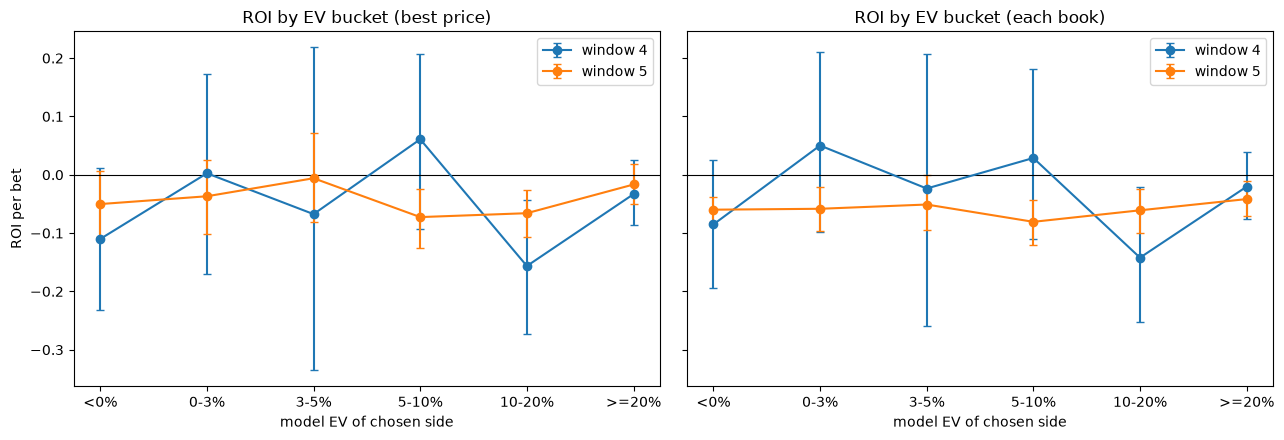

In [78]:
# Diagnostic only: does ROI rise with the model's expected value? Not for picking EDGE_THRESHOLD.
# Every line is assigned its higher-EV side, including lines below the threshold.

if ODDS_PATH.exists():
    bucket_rows = []
    for test_window, fold in fold_results.items():
        test = fold["test"].reset_index(names="row")[["row", "game_key", "player_key", "pts"]]
        m = test.merge(odds, on=["game_key", "player_key"], how="inner")
        if not m.empty:
            p_close = no_vig_over(m["over_close"], m["under_close"])
            for record in ev_bucket_records(model_over(fold, m), m, p_close, n_boot=SCORE_BOOT_REPS, seed=SEED):
                bucket_rows.append({"test_window": test_window, "source": "best price", **record})
        mb = (test.merge(book_odds, on=["game_key", "player_key"], how="inner")
              .merge(consensus_cols, on=["game_key", "player_key"], how="left"))
        if not mb.empty:
            p_consensus = np.where(mb["line"].eq(mb["consensus_line"]),
                                   no_vig_over(mb["over_close"], mb["under_close"]), np.nan)
            for record in ev_bucket_records(model_over(fold, mb), mb, p_consensus, n_boot=SCORE_BOOT_REPS, seed=SEED):
                bucket_rows.append({"test_window": test_window, "source": "each book", **record})

    buckets = pd.DataFrame(bucket_rows)
    print("ROI by model EV bucket. If ROI does not rise with EV, a higher threshold will not help.")
    print("mean_p_consensus_side is NaN for book quotes whose line differs from the consensus line.")
    display(buckets.round(4))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    for ax, (source, g) in zip(axes, buckets.groupby("source")):
        for test_window, gw in g.groupby("test_window"):
            x = np.arange(len(gw))
            ax.errorbar(x, gw["roi"], yerr=[gw["roi"] - gw["roi_ci_low"], gw["roi_ci_high"] - gw["roi"]],
                        marker="o", capsize=3, label=f"window {test_window}")
            ax.set_xticks(x, gw["ev_bucket"].astype(str))
        ax.axhline(0, color="black", lw=0.8)
        ax.set_title(f"ROI by EV bucket ({source})")
        ax.set_xlabel("model EV of chosen side")
        ax.legend()
    axes[0].set_ylabel("ROI per bet")
    plt.tight_layout()
    plt.show()
else:
    print(f"No odds file at {ODDS_PATH.relative_to(ROOT)}; bucket check skipped.")

### 6. Export
The simulation notebook needs the exact family, rotation, parameters, and count model. The `status` field says what the fit is safe for, so nothing prices off an exploratory spec by accident.

In [79]:
log_gain = diffs.set_index(["comparison", "metric"])
b_vs_a = log_gain.loc[("b_copula - a_independent", "log_score")]
c_vs_b = log_gain.loc[("c_direct - b_copula", "log_score")]
c_vs_a = log_gain.loc[("c_direct - a_independent", "log_score")]

export_direct = best_setup == "c_direct"
export_count = (
    fit_count_model(rows["minutes"], rows["pts"], rows["rate_hat"], rate_cv=rows["rate_cv"],
                    surprise=stats.norm.ppf(rows["u_minutes"]))
    if export_direct else count_model
)
log_mu = "log_kappa + beta*log(m) + beta2*log(m/minutes_center)^2 + log(rate_hat)"
if export_direct:
    log_mu += " + gamma*Phi^-1(u_minutes)"

spec = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "status": SPEC_STATUS,
    "status_note": (
        "Fit on pre-holdout walk-forward OOS pairs. Not validated on 2025-26, and the OOS table "
        "predates the current bundles. Do not price from this spec."
    ),
    "pairs": {
        "u_minutes": "randomized PIT of realized minutes under the minutes sampler (copula.build_pit_pairs)",
        "u_points": "randomized PIT of realized points under the NB2 count model below, given actual minutes",
        "column_order": ["u_minutes", "u_points"],
        "n_pairs": int(len(uv)),
        "windows": sorted(int(w) for w in rows["window_id"].unique()),
        "date_range": [str(rows["game_date"].min().date()), str(rows["game_date"].max().date())],
    },
    "copula": {
        "family": export_family,
        "rotation": export_rotation,
        "parameters": exported.parameters.ravel().tolist(),
        "tau": float(exported.tau),
        "loglik": float(exported.loglik(uv)),
        "aic": float(exported.aic(uv)),
        "bootstrap_ci_95": {k: [float(boot_ci.loc[k, "ci_low"]), float(boot_ci.loc[k, "ci_high"])] for k in boot_ci.index},
        "bootstrap": f"{BOOT_REPS} resamples of whole games",
        "pyvinecopulib_json": exported.to_json(),
        "used_in_simulation": not export_direct,
    },
    "count_model": {
        **export_count.to_dict(),
        "rate_hat": f"mean of the rate sampler by {RATE_MEAN_GRID}-point midpoint quadrature",
        "rate_cv": "std / mean of the same quadrature draws",
        "log_mu": log_mu,
        "log_alpha_formula": "log_alpha + alpha_minutes*log(m/minutes_center) + alpha_cv*log(rate_cv)",
        "distribution": "NB2, variance = mu + alpha * mu^2",
    },
    "simulation": (
        "U -> minutes via minutes sampler; V independent uniform; points = NB2 quantile at V given those minutes "
        "and gamma*Phi^-1(U) in log_mu. The copula is not used."
        if export_direct else
        "U -> minutes via minutes sampler; V | U via copula hinv1; points = NB2 quantile at V given those minutes"
    ),
    "selection": {
        "train_windows": list(TRAIN_WINDOWS),
        "test_window": TEST_WINDOW,
        "copula_picked_on_train": copula_tr_label,
        "best_setup_by_test_log_score": best_setup,
        "log_score_b_minus_a": [float(b_vs_a["mean_diff"]), float(b_vs_a["ci_low"]), float(b_vs_a["ci_high"])],
        "log_score_c_minus_a": [float(c_vs_a["mean_diff"]), float(c_vs_a["ci_low"]), float(c_vs_a["ci_high"])],
        "log_score_c_minus_b": [float(c_vs_b["mean_diff"]), float(c_vs_b["ci_low"]), float(c_vs_b["ci_high"])],
        "folds": fold_diffs.to_dict("records"),
    },
    "lineage": {"files": lineage, "versions": versions, "warnings": lineage_warnings},
    "holdout_season": HOLDOUT_SEASON,
    "seed": SEED,
}
SPEC_FILE.write_text(json.dumps(spec, indent=2))
if LEGACY_PICKLE.exists():
    LEGACY_PICKLE.unlink()
print(f"Saved {SPEC_FILE.relative_to(ROOT)} with status '{SPEC_STATUS}'")

Saved artifacts/nba/copula/copula_spec.json with status 'exploratory_oos'


#### Sanity check: rebuild from the JSON
The copula is rebuilt from `copula_spec.json` alone. It must reproduce the log-likelihood, and `N_SANITY_DRAWS` samples must match the empirical Kendall and Spearman within `CORR_TOLERANCE`.

In [80]:
loaded = json.loads(SPEC_FILE.read_text())
rebuilt = pv.Bicop.from_json(loaded["copula"]["pyvinecopulib_json"])
manual = pv.Bicop(
    family=FAMILIES[loaded["copula"]["family"]],
    rotation=loaded["copula"]["rotation"],
    parameters=np.array(loaded["copula"]["parameters"]).reshape(-1, 1),
)
assert np.isclose(rebuilt.loglik(uv), loaded["copula"]["loglik"])
assert np.isclose(manual.loglik(uv), loaded["copula"]["loglik"])

draws = rebuilt.sample(N_SANITY_DRAWS, seeds=[SEED])
check = pd.DataFrame({
    "empirical": [stats.kendalltau(uv[:, 0], uv[:, 1]).statistic, stats.spearmanr(uv[:, 0], uv[:, 1]).statistic],
    "simulated": [stats.kendalltau(draws[:, 0], draws[:, 1]).statistic, stats.spearmanr(draws[:, 0], draws[:, 1]).statistic],
}, index=["kendall", "spearman"])
check["abs_diff"] = (check["simulated"] - check["empirical"]).abs()
display(check.round(4))
assert (check["abs_diff"] <= CORR_TOLERANCE).all()
print("PASS: rebuilt copula matches the stored log-likelihood and the empirical rank correlation.")

,empirical,simulated,abs_diff
kendall,0.0708,0.0704,0.0004
spearman,0.1060,0.1054,0.0006


PASS: rebuilt copula matches the stored log-likelihood and the empirical rank correlation.


### Results

In [81]:
legacy_ll = overall.set_index("pair").loc["u_minutes x u_rate_legacy", "lift_low_u_low_v"]
points_ll = overall.set_index("pair").loc["u_minutes x u_points", "lift_low_u_low_v"]
points_tau = overall.set_index("pair").loc["u_minutes x u_points", "kendall"]
hh_1pct = empirical_tails.query("q == 0.01 and corner == 'high_u_high_v'")["lift"].iloc[0]
ll_1pct = empirical_tails.query("q == 0.01 and corner == 'low_u_low_v'")["lift"].iloc[0]
params_text = ", ".join(f"{p:.3f}" for p in selected.parameters.ravel())
ci_text = "; ".join(f"{k} [{boot_ci.loc[k, 'ci_low']:.3f}, {boot_ci.loc[k, 'ci_high']:.3f}]" for k in boot_ci.index)


def fmt_diff(row) -> str:
    return f"{row['mean_diff']:+.4f} [{row['ci_low']:+.4f}, {row['ci_high']:+.4f}]"


not_flat_text = ", ".join(f"{r.pit} {r.slice}" for r in not_flat.itertuples()) or "none"
display(Markdown(f"""
**- Winner (in-sample, all pre-holdout pairs):** {best_label}, parameters ({params_text}), Kendall tau {selected.tau:.3f}, log-likelihood {selected.loglik(uv):,.1f} on {len(uv):,} pairs. Game-bootstrap 95% CI: {ci_text}.

**- Short-stint effect:** the 10% lower-left lift is {legacy_ll:.2f}x with the legacy rate PIT and {points_ll:.2f}x with points given actual minutes (tau {points_tau:+.3f}). At 1%, lower-left lift is {ll_1pct:.1f}x and upper-right is {hh_1pct:.1f}x.

**- Out-of-sample (window {TEST_WINDOW}):** copula picked on windows 1-4 is {copula_tr_label}. Log score per player-game, copula minus independent: {fmt_diff(b_vs_a)}. Direct minus independent: {fmt_diff(c_vs_a)}. Direct minus copula: {fmt_diff(c_vs_b)}. Best setup by log score: **{best_setup}**.

**- Margins outside PIT tolerance:** {not_flat_text}.

**- Spec status:** `{SPEC_STATUS}`. {len(lineage_warnings)} lineage warning(s).
"""))


**- Winner (in-sample, all pre-holdout pairs):** frank 0, parameters (0.638), Kendall tau 0.071, log-likelihood 435.8 on 75,710 pairs. Game-bootstrap 95% CI: param_1 [0.599, 0.682]; tau [0.066, 0.075].

**- Short-stint effect:** the 10% lower-left lift is 3.75x with the legacy rate PIT and 1.57x with points given actual minutes (tau +0.071). At 1%, lower-left lift is 1.3x and upper-right is 1.8x.

**- Out-of-sample (window 5):** copula picked on windows 1-4 is frank 0. Log score per player-game, copula minus independent: +0.0043 [+0.0033, +0.0054]. Direct minus independent: +0.0022 [+0.0011, +0.0034]. Direct minus copula: -0.0021 [-0.0030, -0.0012]. Best setup by log score: **b_copula**.

**- Margins outside PIT tolerance:** u_minutes tier 31+, u_points all, u_points tier <15, u_points tier 15-24, u_points tier 24-31, u_points tier 31+, u_points actual min (20, 30], u_points actual min (5, 10], u_points actual min (10, 20], u_points actual min (0, 5], u_points actual min (40, 70].

**- Spec status:** `exploratory_oos`. 0 lineage warning(s).


### Conclusion

In [82]:
pooled = fold_diffs.loc[fold_diffs["test_window"].eq("pooled")].set_index("comparison")
per_fold = fold_diffs.loc[fold_diffs["test_window"].ne("pooled")]


def holds(comparison: str, sign: int) -> bool:
    row = pooled.loc[comparison]
    agree = (np.sign(per_fold.loc[per_fold["comparison"] == comparison, "mean_diff"]) == sign).all()
    return bool((row["ci_low"] > 0 if sign > 0 else row["ci_high"] < 0) and agree)


copula_helps = holds("b_copula - a_independent", +1)
direct_beats_copula = holds("c_direct - b_copula", +1)
copula_beats_direct = holds("c_direct - b_copula", -1)
if direct_beats_copula:
    verdict = "On log score, the direct points-given-minutes model beats the copula out of sample, so the copula is not needed for points. Carry the minutes surprise as a feature instead."
elif copula_beats_direct and copula_helps:
    verdict = "On log score, the copula beats both independence and the direct model out of sample."
elif copula_helps:
    verdict = "On log score, the copula beats independence out of sample, but it cannot be separated from the direct model."
else:
    verdict = "On log score, the copula does not beat independence out of sample once points are modelled given actual minutes."

c_minus_b = diffs.loc[diffs["comparison"] == "c_direct - b_copula"].set_index("metric")
favours_direct = [m for m, r in c_minus_b.iterrows() if m != "log_score" and r["ci_high"] < 0]
favours_copula = [m for m, r in c_minus_b.iterrows() if m != "log_score" and r["ci_low"] > 0]
secondary = []
if favours_direct:
    secondary.append(f"the direct model is significantly better on {', '.join(favours_direct)}")
if favours_copula:
    secondary.append(f"the copula is significantly better on {', '.join(favours_copula)}")
tie = [m for m in c_minus_b.index if m != "log_score" and m not in favours_direct + favours_copula]
if tie:
    secondary.append(f"they are not separable on {', '.join(tie)}")
secondary_text = "; ".join(secondary) if secondary else "no secondary metric separates them"
gains = (b_vs_a["mean_diff"], c_vs_a["mean_diff"])
display(Markdown(f"""
**- Verdict:** {verdict} On the secondary metrics, {secondary_text}. Both gains over independence are small: {gains[0]:+.4f} (copula) and {gains[1]:+.4f} (direct) nats per player-game.

**- Margins:** `u_points` is still outside the `pmf_eval` PIT tolerance in some slices, so part of what the copula fits may be count-model misfit rather than dependence. Improve the count model before trusting the tail parameters.

**- Before pricing:** rebuild the OOS table from the current bundles, retrain the rate model with minutes weights, and fit the copula per tier and spread bucket if the segment gains above hold up. Then run the final 2025-26 comparison once.
"""))


**- Verdict:** On log score, the copula beats both independence and the direct model out of sample. On the secondary metrics, the direct model is significantly better on brier fixed 4.5; they are not separable on rps, brier L0. Both gains over independence are small: +0.0043 (copula) and +0.0022 (direct) nats per player-game.

**- Margins:** `u_points` is still outside the `pmf_eval` PIT tolerance in some slices, so part of what the copula fits may be count-model misfit rather than dependence. Improve the count model before trusting the tail parameters.

**- Before pricing:** rebuild the OOS table from the current bundles, retrain the rate model with minutes weights, and fit the copula per tier and spread bucket if the segment gains above hold up. Then run the final 2025-26 comparison once.
